In [1]:
import os
import re
import pickle as pkl
import ast
from collections import Counter
from typing import List, Tuple, Any
from tqdm import tqdm
import time

import pandas as pd
import numpy as np
import calibration as cal

import torch

from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
from llm_unsupervised_conf.metrics import *
from llm_unsupervised_conf.math_utils import stack_embeddings
from llm_unsupervised_conf.calibration import fit_predict_prob_models
from llm_unsupervised_conf.plots import plot_reliability, plot_avg_and_worstcase_by_method, plot_method_comparisons, METHODS_MAP_SHORT

In [3]:
from llm_unsupervised_conf.utils import maybe_add_verbal_conf_row, load_out_df, set_seed

In [4]:
def metric_row(name, scores, correct, n_bins):
    return [
        name,
        get_ece1(scores, correct, n_bins=n_bins),
        get_ece2(scores, correct, n_bins=n_bins),
        get_mce(scores, correct, n_bins=n_bins),
        get_nll(scores, correct),
        brier_score_loss(correct, scores),
        roc_auc_score(correct, scores),
    ]


def run_exp(
    dataset,
    model,
    n=1000,
    k_train=100,
    temp_train=0.7,
    temp_test=0.6,
    prob_models=("ridge_clip",),   # <-- pass a list/tuple of the methods above
    include_verbal_conf=True,
    random_state=42,
    n_bins=12,
    embedding_text="question_response",
    drop_bad_rows=True,
    test_prop=0.6,
    verbose=False,
    include_alt_ablation=True,
    include_question_ablation=True
):
    """
    prob_models controls which embedding->prob models to include.
    Example:
      prob_models=["ridge_clip","ridge_logit","hgb_logit","mlp_logit","isotonic_on_ridge"]
    """

    set_seed(random_state)

    model_name = model.split("/")[-1]

    try:
        out_df, df_save_path = load_out_df(dataset, model_name, n, temp_train, k_train, temp_test, embedding_text, drop_bad_rows)
    except:
        return None

    if include_alt_ablation:
        ablation_df, _ = load_out_df(dataset, model_name, n, temp_train, k_train, temp_test, embedding_text="question_response_gemma", drop_bad_rows=True)
        out_df["alt_embeddings"] = ablation_df["embeddings"]

    if include_question_ablation:
        ablation_df, _ = load_out_df(dataset, model_name, n, temp_train, k_train, temp_test, embedding_text="question", drop_bad_rows=True)
        out_df["question_embeddings"] = ablation_df["embeddings"]

    if verbose or random_state == 0:
        print(dataset, model, "no rows", len(out_df))

    # --------------------
    # Split
    # --------------------
    train_df, test_df = train_test_split(
        out_df,
        test_size=test_prop,
        random_state=random_state,
        shuffle=True,
    )

    X_train = stack_embeddings(train_df, "embeddings")
    y_train = train_df["consistency"].astype(np.float32).to_numpy()  # target in [0,1]

    X_test = stack_embeddings(test_df, "embeddings")

    # These are for evaluation
    con_scores = test_df["consistency"].to_numpy(dtype=float)
    correct = test_df["correct"].to_numpy(dtype=int)

    logprobs = test_df["avg_logprobs"].to_numpy(dtype=float)
    ans_logprobs = test_df["ans_logprobs"].to_numpy(dtype=float)
    lp = np.exp(logprobs)
    alp = np.exp(ans_logprobs)

    if verbose:
        print(f"Results: (accuracy={correct.mean():.4f})")

    ########################
    # Baselines
    ########################
    score_sources = {
        "logprob": lp,
        "ans_logprob": alp,
        "oracle_sc": con_scores,
    }
    
    rows = [metric_row(name, scores, correct, n_bins) for name, scores in score_sources.items()]

    ########################
    # Ours
    ########################
    prob_models = list(prob_models) if prob_models is not None else []
    preds = fit_predict_prob_models(
        X_train=X_train,
        y_train_prob=y_train,
        X_test=X_test,
        methods=prob_models,
        random_state=random_state,
    )

    for method_name, pred_probs in preds.items():
        rows.append(metric_row(method_name, pred_probs, correct, n_bins))

    ########################
    # Verbal Confidence
    ########################
    vc_scores = None
    if include_verbal_conf:
        rows, vc_scores = maybe_add_verbal_conf_row(
            rows, 
            df_save_path, 
            test_df, 
            correct, 
            stem_idx=6
        )

    ########################
    # Alt. Model Embeddings
    ########################

    if include_alt_ablation:
        X_train = stack_embeddings(train_df, "alt_embeddings")
        X_test = stack_embeddings(test_df, "alt_embeddings")
        abl_preds = fit_predict_prob_models(
            X_train=X_train,
            y_train_prob=y_train,
            X_test=X_test,
            methods=prob_models,
            random_state=random_state,
        )
        # abl_probs = abl_preds["split_isotonic_on_ridge"]
        # rows.append(metric_row("blackbox", abl_probs, correct, n_bins))
        for method_name, abl_probs in abl_preds.items():
            rows.append(metric_row(f"blackbox_{method_name}", abl_probs, correct, n_bins))

    ########################
    # Question only embeddings
    ########################

    if include_question_ablation:
        X_train = stack_embeddings(train_df, "question_embeddings")
        X_test = stack_embeddings(test_df, "question_embeddings")
        abl_preds = fit_predict_prob_models(
            X_train=X_train,
            y_train_prob=y_train,
            X_test=X_test,
            methods=prob_models,
            random_state=random_state,
        )
        # abl_probs = abl_preds["split_isotonic_on_ridge"]
        # rows.append(metric_row("question_only", abl_probs, correct, n_bins))
        for method_name, abl_probs in abl_preds.items():
            rows.append(metric_row(f"question_only_{method_name}", abl_probs, correct, n_bins))

    ########################
    # Labeled Recalibration
    ########################
    train_lp = np.exp(train_df["avg_logprobs"].to_numpy(dtype=float))
    train_alp = np.exp(train_df["ans_logprobs"].to_numpy(dtype=float))
    train_con = train_df["consistency"].to_numpy(dtype=float)
    train_correct = train_df["correct"].to_numpy(dtype=int)

    train_scores = {
        "logprob": train_lp,
        "ans_logprob": train_alp,
        "sc": train_con,
    }
    test_scores = {
        "logprob": lp,
        "ans_logprob": alp,
        "sc": con_scores,
    }

    for source_name, probs in train_scores.items():

        # print(source_name, probs.shape)
        
        train_probs = np.zeros((len(probs), 2))
        train_probs[:, 0] = 1-probs
        train_probs[:, 1] = probs

        calibrator = cal.PlattTopCalibrator(len(probs), num_bins=n_bins)
        calibrator.train_calibration(train_probs, train_correct)

        test_probs_temp = test_scores[source_name]
        test_probs = np.zeros((len(test_probs_temp), 2))

        test_probs[:, 0] = 1-test_probs_temp
        test_probs[:, 1] = test_probs_temp
        calibrated_probs = calibrator.calibrate(test_probs)
        
        rows.append(metric_row(f"{source_name}_scaled", calibrated_probs, correct, n_bins))
    
    # --------------------
    # Pack + display
    # --------------------
    exp_df = pd.DataFrame(rows, columns=["Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC"])
    exp_df["Model"] = model
    exp_df["Dataset"] = dataset
    exp_df["Accuracy"] = float(correct.mean())
    exp_df = exp_df[["Model", "Dataset", "Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC", "Accuracy"]]
    if verbose or random_state == 0:
        display(exp_df)
    
    if verbose or random_state == 0:
        print(model, dataset)
        plot_reliability(preds["ridge_clip"], correct, logprobs, ans_logprobs, vc_scores, binning="quantile")

    return exp_df


In [5]:
def run_all_exps(
    models, 
    datasets, 
    exp_key=None, 
    n_trials=10, 
    n_bins=12, 
    test_prop=0.6,
    embedding_text="question_response",
    prob_models = ["ridge_clip","split_isotonic_on_ridge","split_isotonic_on_ridge_nrt"],
):

    full_df = []
    for dataset in datasets:
        print(f"[status] running {dataset}")
        start_time = time.time()
        for model in models:
            print(f"[status] running {model}")
            for seed in range(n_trials):
                df = run_exp(
                    dataset=dataset,
                    model=model,
                    random_state=seed,
                    n_bins=n_bins,
                    test_prop=test_prop,
                    embedding_text=embedding_text,
                    prob_models=prob_models
                )
                if df is None:
                    continue
                df["seed"] = seed
                full_df.append(df)
                
        print("--- %s seconds ---" % (time.time() - start_time))
    
    full_df = pd.concat(full_df)

    if exp_key is not None:
        full_df.to_csv(f"../results/cal_exp_results_{exp_key}.csv", index=False)
        

    display(full_df.head(5))

    show_cols = ["Method", "ECE1", "ECE2", "MCE", "Brier", "AUROC"]
    
    print("AVERAGE")
    display(
        full_df[show_cols].groupby(["Method"]).mean().sort_values(["ECE2"])
    )
    print("WORST")
    grouped_df = full_df[show_cols+["Model", "Dataset"]].groupby(["Model", "Dataset", "Method"]).mean().reset_index()
    display(
        grouped_df[show_cols[:-1]].groupby(["Method"]).max().sort_values(["ECE2"])
    )

    plot_avg_and_worstcase_by_method(
        grouped_df,
        metrics=("ECE1", "ECE2", "MCE", "Brier", "AUROC"),
        method_order=["verbal_conf", "logprob", "ans_logprob", "ridge_clip"],
        show_values=True,
        figsize=(16,3)
    )

    print("----"*10)
    print("--* Dataset comparison *--")
    print("----"*10)

    plot_method_comparisons(
        full_df,
        metrics=["ECE2", "Brier", "AUROC"],
        facet="Dataset",
        dataset_order=datasets,   # optional: order + subset
        model_order=None,                              # None => include all models
        method_order=["verbal_conf", "logprob", "ans_logprob", "ridge_clip"],
        sharey=None
    )

    for dataset in datasets:
        print(dataset)
        dataset_df = full_df[(full_df["Dataset"] == dataset)]
        display(
            dataset_df[["Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC", "Accuracy"]].groupby(["Method"]).mean()
        )

    print("----"*10)
    print("--* Model comparison *--")
    print("----"*10)

    plot_method_comparisons(
        full_df,
        metrics=["ECE2", "Brier", "AUROC"],
        facet="Model",
        model_order=models,  # optional: order + subset
        dataset_order=None,                                # None => include all datasets
        method_order=["verbal_conf", "logprob", "ans_logprob", "ridge_clip"],
    )
    
    for model in models:
        print(model)
        model_df = full_df[(full_df["Model"] == model)]
        display(
            model_df[["Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC", "Accuracy"]].groupby(["Method"]).mean()
        )


In [ ]:
models = [
    "Qwen/Qwen3-0.6B", 
    "Qwen/Qwen3-1.7B", 
    "Qwen/Qwen3-4B-Thinking-2507", 
    "Qwen/Qwen3-8B",
    "Qwen/Qwen3-14B",
    "nvidia/OpenReasoning-Nemotron-7B",
    "nvidia/Nemotron-Cascade-8B-Thinking",
    "deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
]
datasets = [
    "gsm8k",
    "polymath",
    "trivia_qa",
    "sciq",
    "webq"
]
# exp_key = "all"
# n_trials = 200

exp_key = "test"
n_trials = 1

run_all_exps(models, datasets, exp_key, n_trials)

[status] running gsm8k
[status] running Qwen/Qwen3-0.6B
gsm8k Qwen/Qwen3-0.6B no rows 998


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-0.6B,gsm8k,logprob,0.074230,0.087404,0.149404,0.471943,0.149191,0.689263,0.806344
1,Qwen/Qwen3-0.6B,gsm8k,ans_logprob,0.189862,0.250154,0.634738,1.869455,0.187854,0.727324,0.806344
2,Qwen/Qwen3-0.6B,gsm8k,oracle_sc,0.053940,0.071886,0.169434,0.419116,0.103103,0.871064,0.806344
3,Qwen/Qwen3-0.6B,gsm8k,ridge_clip,0.093570,0.103760,0.187311,0.858076,0.155720,0.651103,0.806344
4,Qwen/Qwen3-0.6B,gsm8k,split_isotonic_on_ridge,0.060409,0.066279,0.110943,0.521132,0.151273,0.650559,0.806344
5,Qwen/Qwen3-0.6B,gsm8k,split_isotonic_on_ridge_nrt,0.070453,0.080804,0.132347,0.481559,0.149999,0.678348,0.806344
6,Qwen/Qwen3-0.6B,gsm8k,verbal_conf,0.188912,0.236659,0.579710,2.462499,0.204393,0.663686,0.806344
7,Qwen/Qwen3-0.6B,gsm8k,blackbox_ridge_clip,0.059485,0.067437,0.120997,0.576950,0.135890,0.745645,0.806344
8,Qwen/Qwen3-0.6B,gsm8k,blackbox_split_isotonic_on_ridge,0.069685,0.092068,0.230408,0.456221,0.139618,0.740014,0.806344
9,Qwen/Qwen3-0.6B,gsm8k,blackbox_split_isotonic_on_ridge_nrt,0.069017,0.089292,0.245227,0.463393,0.144594,0.717150,0.806344


Qwen/Qwen3-0.6B gsm8k


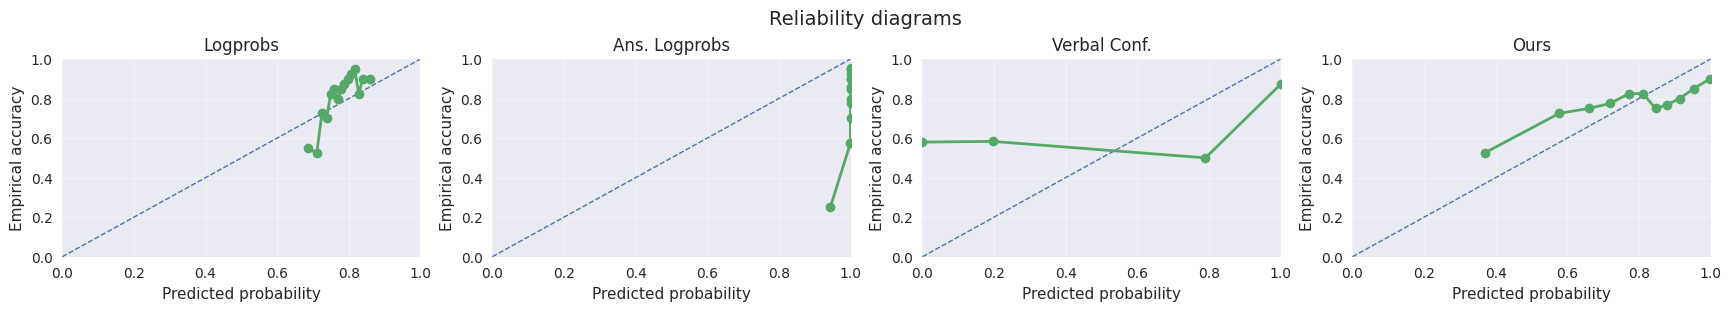

[status] running Qwen/Qwen3-1.7B
gsm8k Qwen/Qwen3-1.7B no rows 999


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-1.7B,gsm8k,logprob,0.033963,0.042120,0.080217,0.300298,0.082599,0.679425,0.906667
1,Qwen/Qwen3-1.7B,gsm8k,ans_logprob,0.089557,0.089557,0.089557,1.135165,0.091642,0.610590,0.906667
2,Qwen/Qwen3-1.7B,gsm8k,oracle_sc,0.056967,0.067996,0.180000,0.565186,0.069481,0.767053,0.906667
3,Qwen/Qwen3-1.7B,gsm8k,ridge_clip,0.042843,0.047031,0.062235,0.508977,0.076784,0.688912,0.906667
4,Qwen/Qwen3-1.7B,gsm8k,split_isotonic_on_ridge,0.054930,0.060932,0.100612,0.356790,0.079606,0.684234,0.906667
5,Qwen/Qwen3-1.7B,gsm8k,split_isotonic_on_ridge_nrt,0.056343,0.066178,0.111784,0.338171,0.080469,0.700466,0.906667
6,Qwen/Qwen3-1.7B,gsm8k,verbal_conf,0.093278,0.116308,0.314197,1.288098,0.098252,0.622243,0.906667
7,Qwen/Qwen3-1.7B,gsm8k,blackbox_ridge_clip,0.046979,0.054819,0.113821,0.374539,0.075354,0.740382,0.906667
8,Qwen/Qwen3-1.7B,gsm8k,blackbox_split_isotonic_on_ridge,0.056980,0.075298,0.170655,0.305775,0.078660,0.728466,0.906667
9,Qwen/Qwen3-1.7B,gsm8k,blackbox_split_isotonic_on_ridge_nrt,0.055729,0.068729,0.168408,0.330259,0.079566,0.677652,0.906667


Qwen/Qwen3-1.7B gsm8k


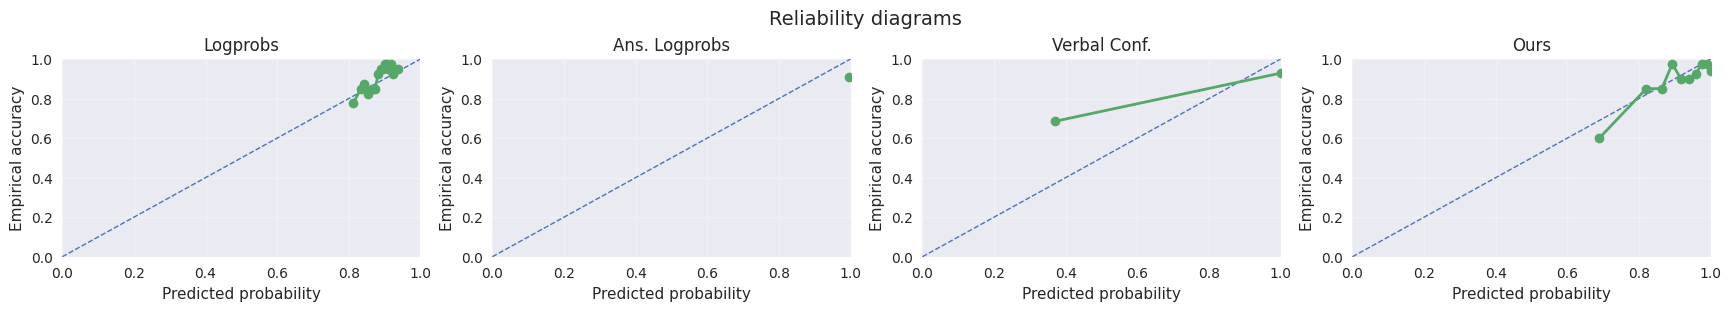

[status] running Qwen/Qwen3-4B-Thinking-2507
gsm8k Qwen/Qwen3-4B-Thinking-2507 no rows 1000


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-4B-Thinking-2507,gsm8k,logprob,0.035963,0.041005,0.075524,0.223776,0.055248,0.642882,0.941667
1,Qwen/Qwen3-4B-Thinking-2507,gsm8k,ans_logprob,0.057544,0.057544,0.057544,0.718075,0.057276,0.605335,0.941667
2,Qwen/Qwen3-4B-Thinking-2507,gsm8k,oracle_sc,0.040267,0.042280,0.082115,0.472337,0.047970,0.711934,0.941667
3,Qwen/Qwen3-4B-Thinking-2507,gsm8k,ridge_clip,0.035201,0.040250,0.073491,0.317806,0.054511,0.668217,0.941667
4,Qwen/Qwen3-4B-Thinking-2507,gsm8k,split_isotonic_on_ridge,0.038002,0.042295,0.061984,0.241580,0.055655,0.651833,0.941667
5,Qwen/Qwen3-4B-Thinking-2507,gsm8k,split_isotonic_on_ridge_nrt,0.039990,0.043603,0.062526,0.247849,0.055988,0.635752,0.941667
6,Qwen/Qwen3-4B-Thinking-2507,gsm8k,verbal_conf,0.054099,0.054336,0.063605,0.699675,0.064071,0.573603,0.941667
7,Qwen/Qwen3-4B-Thinking-2507,gsm8k,blackbox_ridge_clip,0.030229,0.032794,0.055131,0.346005,0.052373,0.688723,0.941667
8,Qwen/Qwen3-4B-Thinking-2507,gsm8k,blackbox_split_isotonic_on_ridge,0.038005,0.043307,0.059212,0.261485,0.054228,0.654008,0.941667
9,Qwen/Qwen3-4B-Thinking-2507,gsm8k,blackbox_split_isotonic_on_ridge_nrt,0.040883,0.048497,0.089978,0.244436,0.054328,0.700480,0.941667


Qwen/Qwen3-4B-Thinking-2507 gsm8k


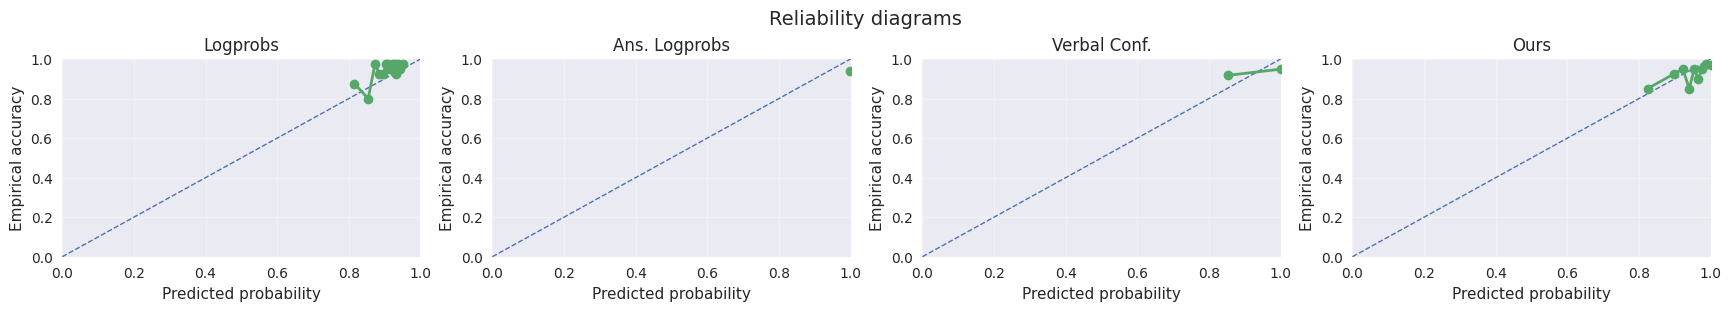

[status] running Qwen/Qwen3-8B
gsm8k Qwen/Qwen3-8B no rows 999


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-8B,gsm8k,logprob,0.055322,0.060980,0.098221,0.207354,0.048784,0.698889,0.95
1,Qwen/Qwen3-8B,gsm8k,ans_logprob,0.049138,0.049138,0.049138,0.612790,0.049135,0.611988,0.95
2,Qwen/Qwen3-8B,gsm8k,oracle_sc,0.034700,0.047074,0.140200,0.379867,0.042004,0.734474,0.95
3,Qwen/Qwen3-8B,gsm8k,ridge_clip,0.024685,0.028074,0.054495,0.264772,0.045082,0.717427,0.95
4,Qwen/Qwen3-8B,gsm8k,split_isotonic_on_ridge,0.033571,0.042688,0.093383,0.252227,0.047536,0.695234,0.95
5,Qwen/Qwen3-8B,gsm8k,split_isotonic_on_ridge_nrt,0.035895,0.044729,0.093383,0.238564,0.047886,0.662807,0.95
6,Qwen/Qwen3-8B,gsm8k,verbal_conf,0.040424,0.045944,0.092744,0.649121,0.055075,0.678450,0.95
7,Qwen/Qwen3-8B,gsm8k,blackbox_ridge_clip,0.030945,0.035608,0.072350,0.304007,0.045611,0.680117,0.95
8,Qwen/Qwen3-8B,gsm8k,blackbox_split_isotonic_on_ridge,0.033655,0.038867,0.068202,0.273500,0.046947,0.673538,0.95
9,Qwen/Qwen3-8B,gsm8k,blackbox_split_isotonic_on_ridge_nrt,0.035513,0.038085,0.062980,0.319045,0.047988,0.599211,0.95


Qwen/Qwen3-8B gsm8k


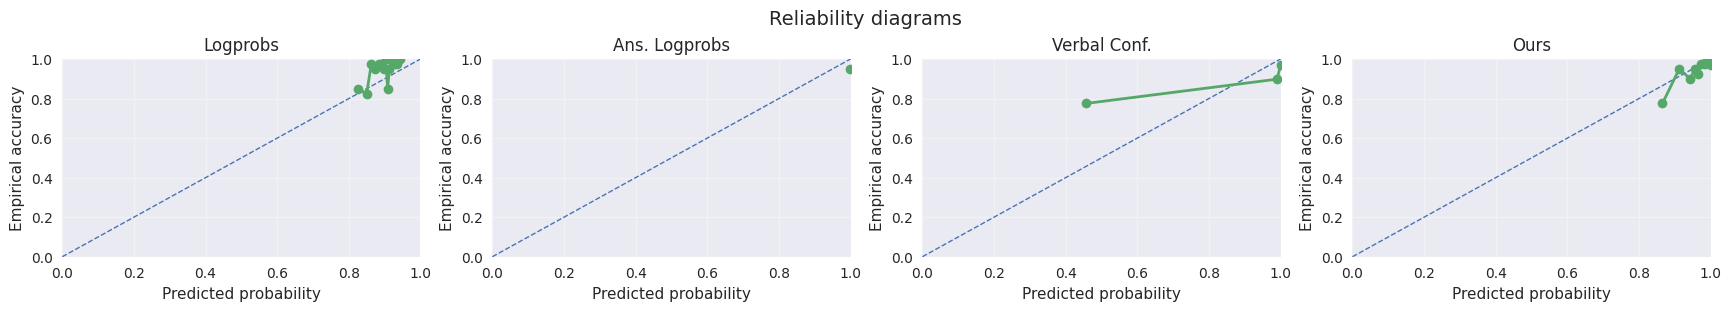

[status] running Qwen/Qwen3-14B
gsm8k Qwen/Qwen3-14B no rows 997


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-14B,gsm8k,logprob,0.037748,0.042542,0.068037,0.215889,0.053821,0.678622,0.941569
1,Qwen/Qwen3-14B,gsm8k,ans_logprob,0.056007,0.056007,0.056007,0.665339,0.057035,0.633029,0.941569
2,Qwen/Qwen3-14B,gsm8k,oracle_sc,0.043673,0.051417,0.126552,0.440286,0.047675,0.735309,0.941569
3,Qwen/Qwen3-14B,gsm8k,ridge_clip,0.039971,0.040890,0.056809,0.405091,0.054219,0.601570,0.941569
4,Qwen/Qwen3-14B,gsm8k,split_isotonic_on_ridge,0.044252,0.046171,0.058741,0.328618,0.054973,0.599899,0.941569
5,Qwen/Qwen3-14B,gsm8k,split_isotonic_on_ridge_nrt,0.044441,0.047651,0.061955,0.362118,0.056553,0.534980,0.941569
6,Qwen/Qwen3-14B,gsm8k,verbal_conf,0.038047,0.038149,0.040214,0.490678,0.054189,0.639919,0.941569
7,Qwen/Qwen3-14B,gsm8k,blackbox_ridge_clip,0.035558,0.039592,0.048581,0.433383,0.054802,0.590653,0.941569
8,Qwen/Qwen3-14B,gsm8k,blackbox_split_isotonic_on_ridge,0.038221,0.041176,0.050622,0.322278,0.054986,0.594782,0.941569
9,Qwen/Qwen3-14B,gsm8k,blackbox_split_isotonic_on_ridge_nrt,0.044469,0.047726,0.078928,0.327677,0.055459,0.580952,0.941569


Qwen/Qwen3-14B gsm8k


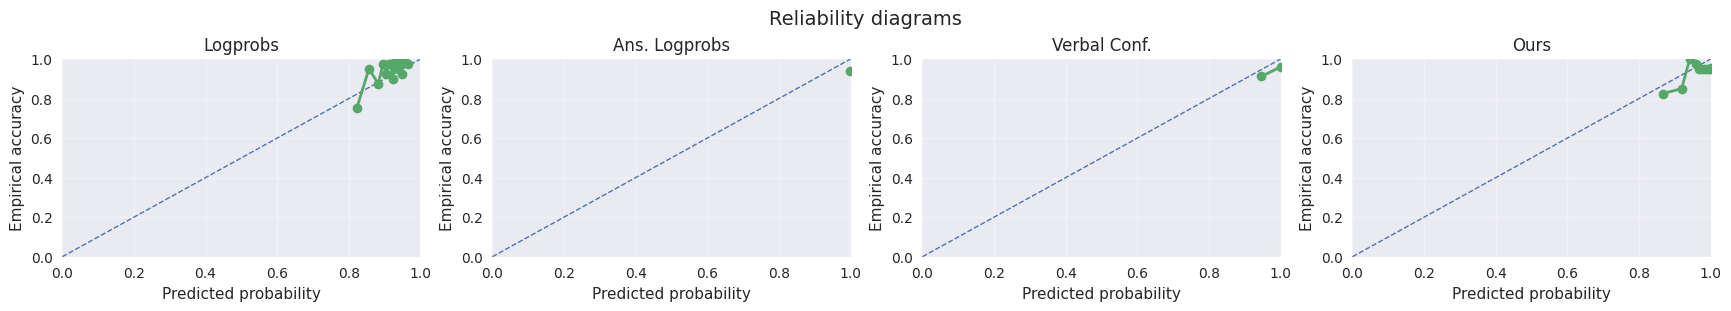

[status] running nvidia/OpenReasoning-Nemotron-7B
gsm8k nvidia/OpenReasoning-Nemotron-7B no rows 989


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,nvidia/OpenReasoning-Nemotron-7B,gsm8k,logprob,0.053997,0.059291,0.096317,0.346386,0.097870,0.627134,0.890572
1,nvidia/OpenReasoning-Nemotron-7B,gsm8k,ans_logprob,0.105295,0.121970,0.244655,0.945262,0.109184,0.435931,0.890572
2,nvidia/OpenReasoning-Nemotron-7B,gsm8k,oracle_sc,0.065118,0.103018,0.279800,0.394063,0.078022,0.871601,0.890572
3,nvidia/OpenReasoning-Nemotron-7B,gsm8k,ridge_clip,0.059514,0.092066,0.249018,0.336840,0.083670,0.847928,0.890572
4,nvidia/OpenReasoning-Nemotron-7B,gsm8k,split_isotonic_on_ridge,0.055379,0.087013,0.249010,0.329961,0.084452,0.827308,0.890572
5,nvidia/OpenReasoning-Nemotron-7B,gsm8k,split_isotonic_on_ridge_nrt,0.059865,0.069558,0.143610,0.364296,0.091838,0.750065,0.890572
6,nvidia/OpenReasoning-Nemotron-7B,gsm8k,verbal_conf,0.212017,0.347088,0.780446,1.862983,0.221404,0.559794,0.890572
7,nvidia/OpenReasoning-Nemotron-7B,gsm8k,blackbox_ridge_clip,0.063528,0.100148,0.273066,0.403883,0.081099,0.816024,0.890572
8,nvidia/OpenReasoning-Nemotron-7B,gsm8k,blackbox_split_isotonic_on_ridge,0.047418,0.066403,0.110984,0.326165,0.079968,0.785910,0.890572
9,nvidia/OpenReasoning-Nemotron-7B,gsm8k,blackbox_split_isotonic_on_ridge_nrt,0.066171,0.086633,0.155791,0.326570,0.088002,0.771645,0.890572


nvidia/OpenReasoning-Nemotron-7B gsm8k


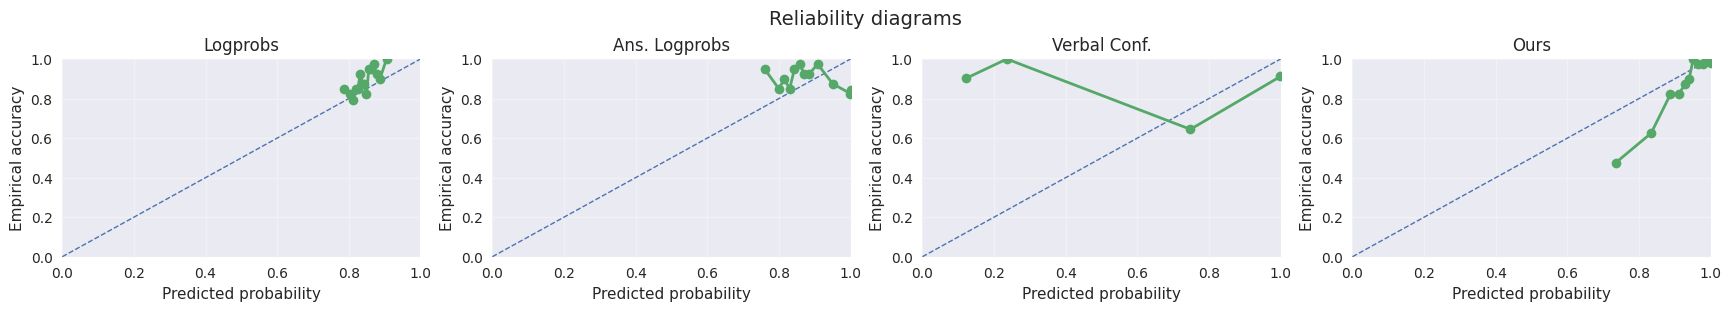

[status] running nvidia/Nemotron-Cascade-8B-Thinking
gsm8k nvidia/Nemotron-Cascade-8B-Thinking no rows 996


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,nvidia/Nemotron-Cascade-8B-Thinking,gsm8k,logprob,0.039372,0.054713,0.132439,0.280209,0.073465,0.602121,0.919732
1,nvidia/Nemotron-Cascade-8B-Thinking,gsm8k,ans_logprob,0.064095,0.071756,0.141742,0.774552,0.078588,0.571193,0.919732
2,nvidia/Nemotron-Cascade-8B-Thinking,gsm8k,oracle_sc,0.050351,0.056357,0.115400,0.474118,0.067268,0.778011,0.919732
3,nvidia/Nemotron-Cascade-8B-Thinking,gsm8k,ridge_clip,0.045881,0.053653,0.127924,0.384214,0.070273,0.735530,0.919732
4,nvidia/Nemotron-Cascade-8B-Thinking,gsm8k,split_isotonic_on_ridge,0.056789,0.075253,0.183137,0.310673,0.072990,0.722064,0.919732
5,nvidia/Nemotron-Cascade-8B-Thinking,gsm8k,split_isotonic_on_ridge_nrt,0.054155,0.061530,0.130240,0.310700,0.073536,0.666515,0.919732
6,nvidia/Nemotron-Cascade-8B-Thinking,gsm8k,verbal_conf,0.059445,0.060555,0.064078,0.864242,0.073385,0.606534,0.919732
7,nvidia/Nemotron-Cascade-8B-Thinking,gsm8k,blackbox_ridge_clip,0.045568,0.070296,0.217983,0.378850,0.067959,0.736402,0.919732
8,nvidia/Nemotron-Cascade-8B-Thinking,gsm8k,blackbox_split_isotonic_on_ridge,0.054450,0.090015,0.267054,0.310486,0.071261,0.712784,0.919732
9,nvidia/Nemotron-Cascade-8B-Thinking,gsm8k,blackbox_split_isotonic_on_ridge_nrt,0.052889,0.075717,0.496742,0.328127,0.072824,0.619451,0.919732


nvidia/Nemotron-Cascade-8B-Thinking gsm8k


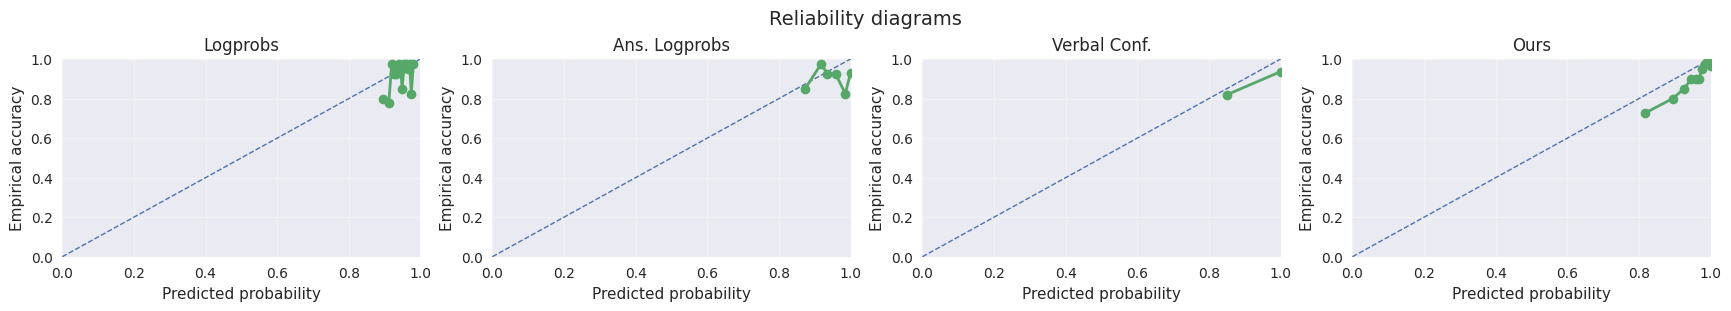

[status] running deepseek-ai/DeepSeek-R1-Distill-Llama-8B
gsm8k deepseek-ai/DeepSeek-R1-Distill-Llama-8B no rows 965


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,gsm8k,logprob,0.158515,0.163378,0.218573,0.465528,0.141765,0.545967,0.861831
1,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,gsm8k,ans_logprob,0.134785,0.172840,0.490628,1.513555,0.132603,0.686022,0.861831
2,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,gsm8k,oracle_sc,0.037168,0.052950,0.150417,0.339033,0.094040,0.844401,0.861831
3,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,gsm8k,ridge_clip,0.050740,0.056530,0.090959,0.556518,0.112726,0.669514,0.861831
4,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,gsm8k,split_isotonic_on_ridge,0.049992,0.057832,0.104676,0.394711,0.114382,0.663051,0.861831
5,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,gsm8k,split_isotonic_on_ridge_nrt,0.050051,0.055354,0.129524,0.402460,0.117078,0.640544,0.861831
6,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,gsm8k,verbal_conf,0.132450,0.184718,0.512234,0.747549,0.149901,0.630574,0.861831
7,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,gsm8k,blackbox_ridge_clip,0.052526,0.060372,0.094666,0.543253,0.112690,0.655110,0.861831
8,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,gsm8k,blackbox_split_isotonic_on_ridge,0.049570,0.057250,0.114128,0.386976,0.112207,0.641533,0.861831
9,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,gsm8k,blackbox_split_isotonic_on_ridge_nrt,0.053555,0.067141,0.113302,0.392701,0.114179,0.663164,0.861831


deepseek-ai/DeepSeek-R1-Distill-Llama-8B gsm8k


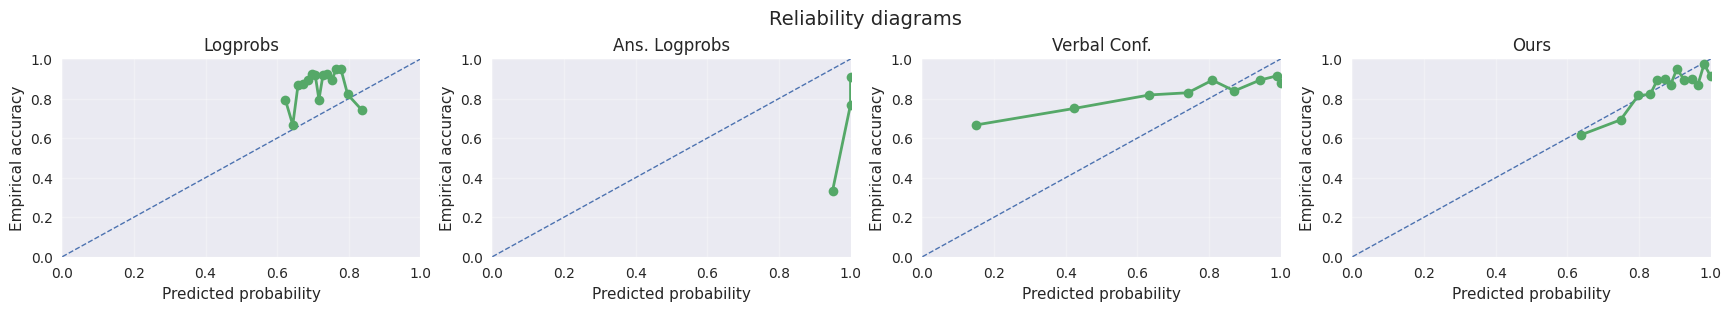

[status] running deepseek-ai/DeepSeek-R1-Distill-Qwen-7B
gsm8k deepseek-ai/DeepSeek-R1-Distill-Qwen-7B no rows 990


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,gsm8k,logprob,0.138214,0.149190,0.206437,0.393079,0.110685,0.589732,0.89899
1,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,gsm8k,ans_logprob,0.099636,0.179690,0.583709,0.985321,0.098519,0.778870,0.89899
2,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,gsm8k,oracle_sc,0.043232,0.049438,0.090147,0.437918,0.075672,0.790278,0.89899
3,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,gsm8k,ridge_clip,0.041054,0.048632,0.093600,0.468339,0.083112,0.692946,0.89899
4,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,gsm8k,split_isotonic_on_ridge,0.061116,0.078321,0.157296,0.386021,0.088679,0.670490,0.89899
5,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,gsm8k,split_isotonic_on_ridge_nrt,0.056947,0.078027,0.157385,0.337196,0.084663,0.745115,0.89899
6,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,gsm8k,verbal_conf,0.097700,0.144859,0.450400,1.114917,0.106133,0.670225,0.89899
7,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,gsm8k,blackbox_ridge_clip,0.048579,0.056485,0.094642,0.539870,0.083079,0.669507,0.89899
8,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,gsm8k,blackbox_split_isotonic_on_ridge,0.059464,0.082110,0.229830,0.381520,0.088131,0.668071,0.89899
9,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,gsm8k,blackbox_split_isotonic_on_ridge_nrt,0.057403,0.072389,0.156068,0.345662,0.088392,0.677856,0.89899


deepseek-ai/DeepSeek-R1-Distill-Qwen-7B gsm8k


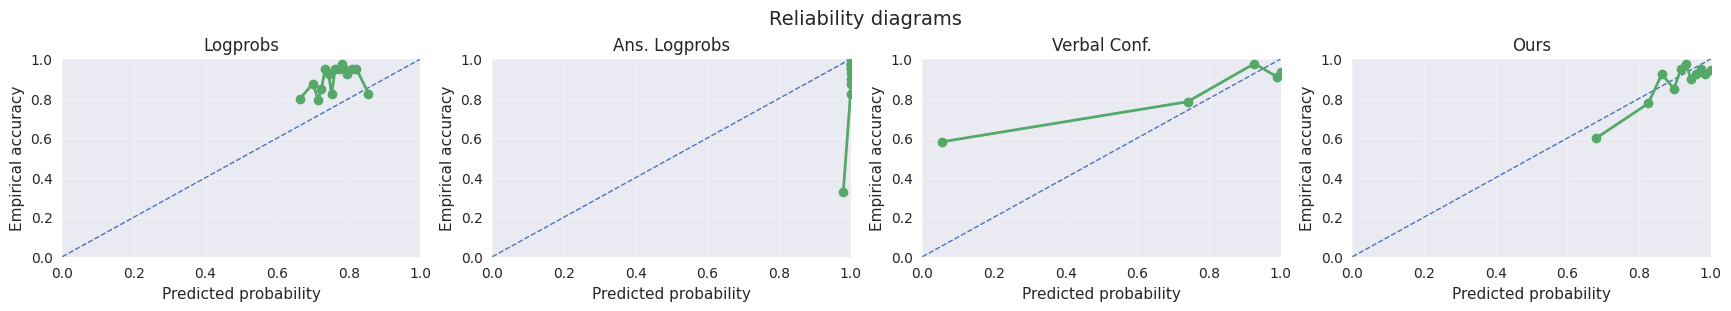

--- 1365.1770787239075 seconds ---
[status] running polymath
[status] running Qwen/Qwen3-0.6B
polymath Qwen/Qwen3-0.6B no rows 997


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-0.6B,polymath,logprob,0.145172,0.171584,0.330017,0.640435,0.224801,0.699653,0.659432
1,Qwen/Qwen3-0.6B,polymath,ans_logprob,0.335898,0.393943,0.724602,3.336331,0.334070,0.740692,0.659432
2,Qwen/Qwen3-0.6B,polymath,oracle_sc,0.099533,0.113923,0.192745,0.542817,0.157416,0.851086,0.659432
3,Qwen/Qwen3-0.6B,polymath,ridge_clip,0.095555,0.115238,0.168739,0.945300,0.215737,0.685840,0.659432
4,Qwen/Qwen3-0.6B,polymath,split_isotonic_on_ridge,0.125622,0.142240,0.213348,0.646705,0.220235,0.680231,0.659432
5,Qwen/Qwen3-0.6B,polymath,split_isotonic_on_ridge_nrt,0.111716,0.126713,0.215402,0.620547,0.212107,0.702873,0.659432
6,Qwen/Qwen3-0.6B,polymath,verbal_conf,0.324077,0.337378,0.504132,4.162023,0.331754,0.604083,0.659432
7,Qwen/Qwen3-0.6B,polymath,blackbox_ridge_clip,0.092576,0.100281,0.162172,0.638852,0.179293,0.787776,0.659432
8,Qwen/Qwen3-0.6B,polymath,blackbox_split_isotonic_on_ridge,0.119996,0.153843,0.260025,0.567623,0.193953,0.788496,0.659432
9,Qwen/Qwen3-0.6B,polymath,blackbox_split_isotonic_on_ridge_nrt,0.097172,0.129409,0.243714,0.575707,0.195814,0.757241,0.659432


Qwen/Qwen3-0.6B polymath


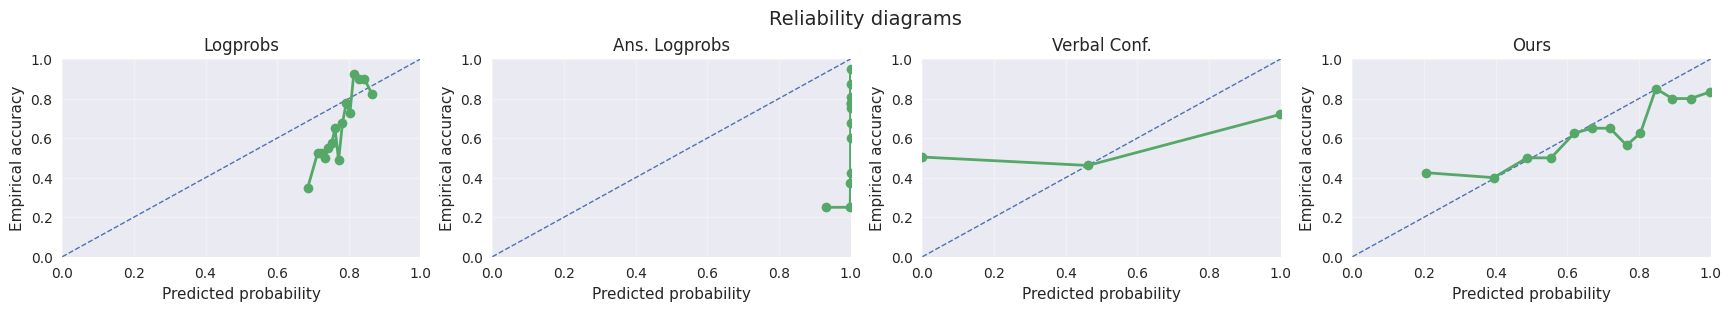

[status] running Qwen/Qwen3-1.7B
polymath Qwen/Qwen3-1.7B no rows 1000


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-1.7B,polymath,logprob,0.088930,0.117873,0.248947,0.402842,0.124607,0.779592,0.846667
1,Qwen/Qwen3-1.7B,polymath,ans_logprob,0.150213,0.174165,0.442557,1.793625,0.148545,0.649146,0.846667
2,Qwen/Qwen3-1.7B,polymath,oracle_sc,0.078183,0.114865,0.235849,0.399303,0.099471,0.887303,0.846667
3,Qwen/Qwen3-1.7B,polymath,ridge_clip,0.049998,0.057622,0.109586,0.529006,0.110422,0.772574,0.846667
4,Qwen/Qwen3-1.7B,polymath,split_isotonic_on_ridge,0.058523,0.068115,0.108459,0.396689,0.113589,0.761501,0.846667
5,Qwen/Qwen3-1.7B,polymath,split_isotonic_on_ridge_nrt,0.068651,0.083700,0.121148,0.407691,0.120300,0.747208,0.846667
6,Qwen/Qwen3-1.7B,polymath,verbal_conf,0.139641,0.184683,0.500000,1.768347,0.146125,0.703943,0.846667
7,Qwen/Qwen3-1.7B,polymath,blackbox_ridge_clip,0.072333,0.096488,0.260055,0.448137,0.107676,0.798528,0.846667
8,Qwen/Qwen3-1.7B,polymath,blackbox_split_isotonic_on_ridge,0.064427,0.093451,0.240596,0.373944,0.113376,0.791649,0.846667
9,Qwen/Qwen3-1.7B,polymath,blackbox_split_isotonic_on_ridge_nrt,0.066536,0.121104,0.334057,0.364355,0.112157,0.806038,0.846667


Qwen/Qwen3-1.7B polymath


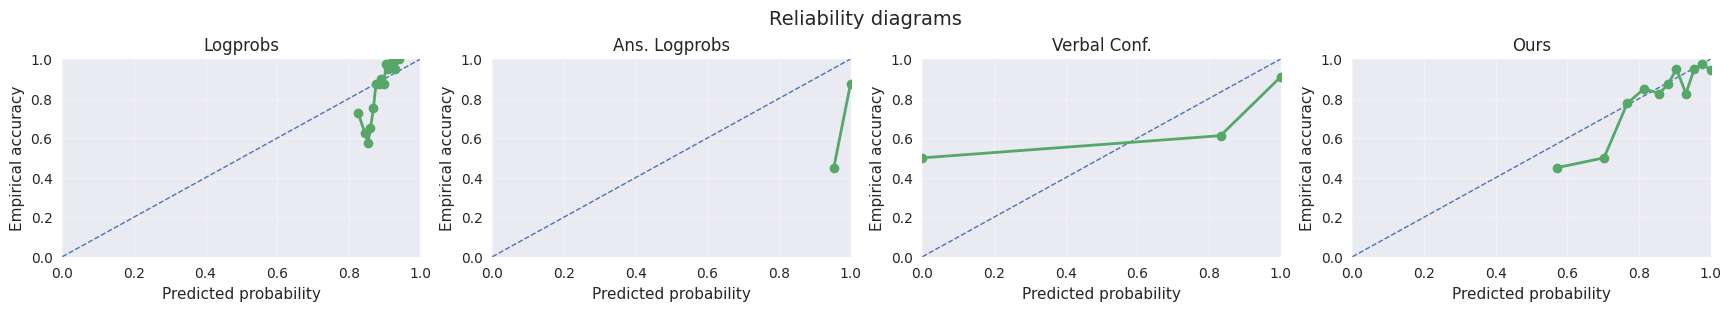

[status] running Qwen/Qwen3-4B-Thinking-2507
polymath Qwen/Qwen3-4B-Thinking-2507 no rows 999


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-4B-Thinking-2507,polymath,logprob,0.072067,0.084095,0.167832,0.314571,0.085228,0.649403,0.91
1,Qwen/Qwen3-4B-Thinking-2507,polymath,ans_logprob,0.086217,0.173103,0.558727,0.891701,0.085198,0.789377,0.91
2,Qwen/Qwen3-4B-Thinking-2507,polymath,oracle_sc,0.057633,0.111777,0.332800,0.314343,0.056304,0.902574,0.91
3,Qwen/Qwen3-4B-Thinking-2507,polymath,ridge_clip,0.033268,0.060873,0.197595,0.286359,0.066082,0.851886,0.91
4,Qwen/Qwen3-4B-Thinking-2507,polymath,split_isotonic_on_ridge,0.062695,0.100990,0.297115,0.292584,0.071743,0.842440,0.91
5,Qwen/Qwen3-4B-Thinking-2507,polymath,split_isotonic_on_ridge_nrt,0.058316,0.078978,0.188904,0.302709,0.075042,0.813272,0.91
6,Qwen/Qwen3-4B-Thinking-2507,polymath,verbal_conf,0.089100,0.098125,0.203033,1.111683,0.110163,0.558557,0.91
7,Qwen/Qwen3-4B-Thinking-2507,polymath,blackbox_ridge_clip,0.042083,0.065961,0.170602,0.353318,0.069341,0.806285,0.91
8,Qwen/Qwen3-4B-Thinking-2507,polymath,blackbox_split_isotonic_on_ridge,0.060344,0.091457,0.225716,0.288090,0.072925,0.806658,0.91
9,Qwen/Qwen3-4B-Thinking-2507,polymath,blackbox_split_isotonic_on_ridge_nrt,0.060992,0.092081,0.228876,0.301516,0.071601,0.796975,0.91


Qwen/Qwen3-4B-Thinking-2507 polymath


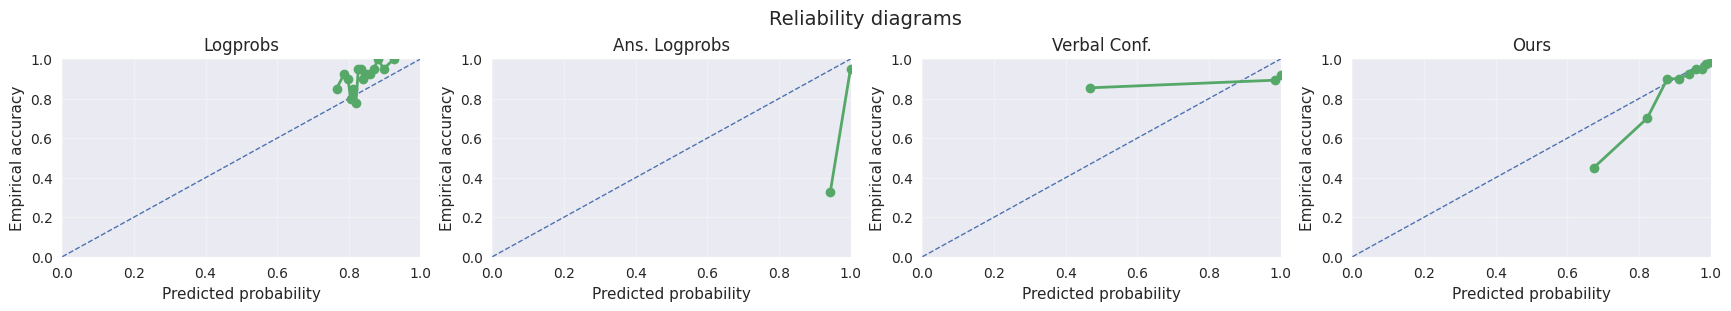

[status] running Qwen/Qwen3-8B
polymath Qwen/Qwen3-8B no rows 1000


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-8B,polymath,logprob,0.064064,0.071053,0.113774,0.244488,0.062598,0.802304,0.931667
1,Qwen/Qwen3-8B,polymath,ans_logprob,0.065979,0.099219,0.311748,0.695664,0.064565,0.742244,0.931667
2,Qwen/Qwen3-8B,polymath,oracle_sc,0.036300,0.061985,0.194808,0.285058,0.047045,0.865461,0.931667
3,Qwen/Qwen3-8B,polymath,ridge_clip,0.031322,0.037307,0.092558,0.337764,0.057686,0.752869,0.931667
4,Qwen/Qwen3-8B,polymath,split_isotonic_on_ridge,0.047487,0.067252,0.148172,0.292482,0.061990,0.739474,0.931667
5,Qwen/Qwen3-8B,polymath,split_isotonic_on_ridge_nrt,0.045403,0.061707,0.155144,0.265090,0.062543,0.754810,0.931667
6,Qwen/Qwen3-8B,polymath,verbal_conf,0.040885,0.041415,0.055538,0.553004,0.063363,0.718509,0.931667
7,Qwen/Qwen3-8B,polymath,blackbox_ridge_clip,0.040391,0.053465,0.147780,0.362506,0.058051,0.722850,0.931667
8,Qwen/Qwen3-8B,polymath,blackbox_split_isotonic_on_ridge,0.044098,0.074580,0.215370,0.293046,0.060871,0.735961,0.931667
9,Qwen/Qwen3-8B,polymath,blackbox_split_isotonic_on_ridge_nrt,0.049319,0.077880,0.196537,0.243571,0.060880,0.785113,0.931667


Qwen/Qwen3-8B polymath


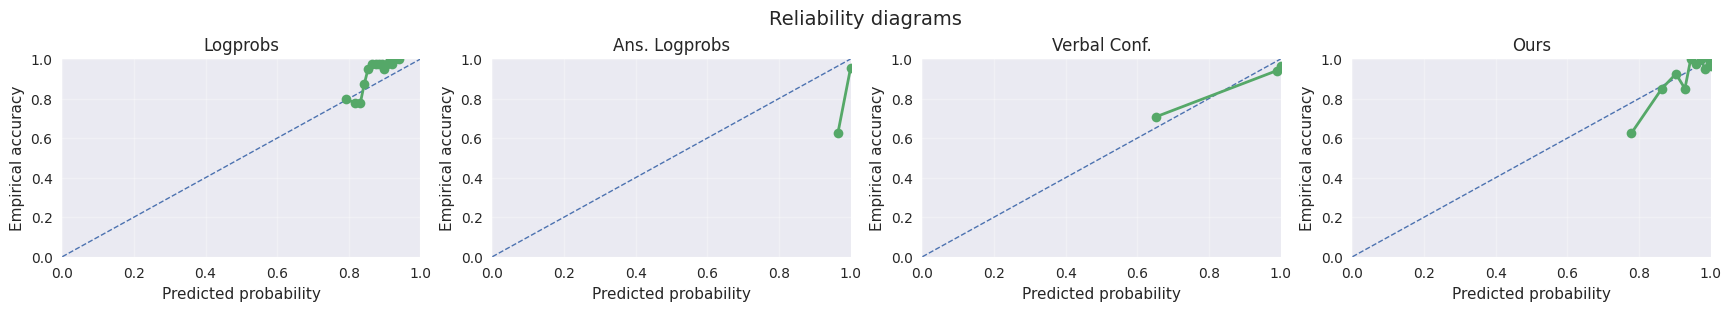

[status] running Qwen/Qwen3-14B
polymath Qwen/Qwen3-14B no rows 996


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-14B,polymath,logprob,0.054123,0.061462,0.101725,0.263650,0.072100,0.767883,0.916388
1,Qwen/Qwen3-14B,polymath,ans_logprob,0.081042,0.152639,0.509260,0.796711,0.079677,0.761661,0.916388
2,Qwen/Qwen3-14B,polymath,oracle_sc,0.053679,0.108692,0.315800,0.284400,0.056699,0.910493,0.916388
3,Qwen/Qwen3-14B,polymath,ridge_clip,0.046237,0.059651,0.155730,0.375134,0.069885,0.770474,0.916388
4,Qwen/Qwen3-14B,polymath,split_isotonic_on_ridge,0.050180,0.067592,0.146051,0.384444,0.072744,0.768741,0.916388
5,Qwen/Qwen3-14B,polymath,split_isotonic_on_ridge_nrt,0.052243,0.072421,0.131801,0.312189,0.074615,0.801223,0.916388
6,Qwen/Qwen3-14B,polymath,verbal_conf,0.061120,0.061124,0.061796,0.640080,0.079259,0.617774,0.916388
7,Qwen/Qwen3-14B,polymath,blackbox_ridge_clip,0.041251,0.056378,0.121489,0.324945,0.073122,0.776861,0.916388
8,Qwen/Qwen3-14B,polymath,blackbox_split_isotonic_on_ridge,0.057575,0.070327,0.107601,0.342409,0.075330,0.765566,0.916388
9,Qwen/Qwen3-14B,polymath,blackbox_split_isotonic_on_ridge_nrt,0.056220,0.062457,0.118476,0.362786,0.075032,0.737865,0.916388


Qwen/Qwen3-14B polymath


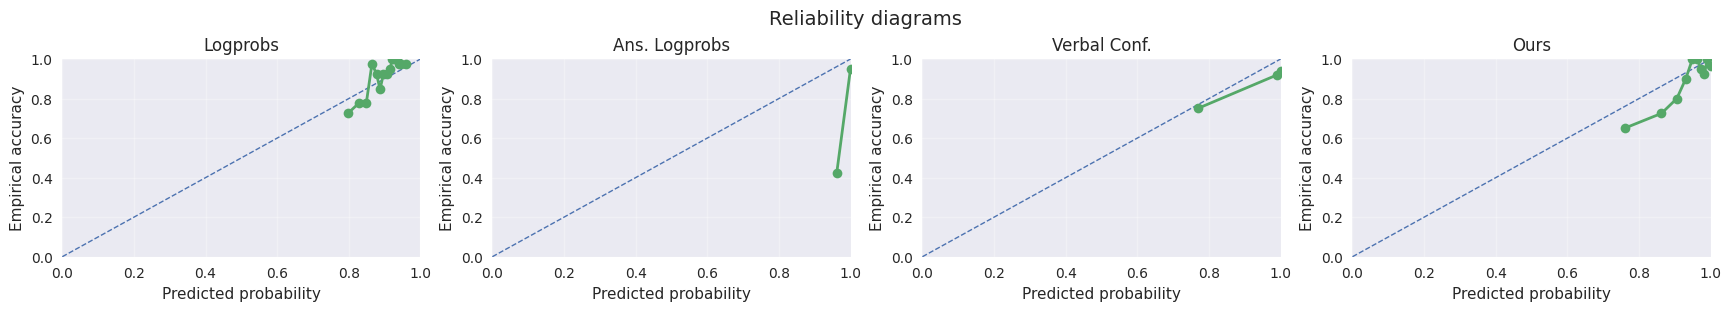

[status] running nvidia/OpenReasoning-Nemotron-7B
polymath nvidia/OpenReasoning-Nemotron-7B no rows 923


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,nvidia/OpenReasoning-Nemotron-7B,polymath,logprob,0.061667,0.072513,0.132814,0.472418,0.149621,0.600214,0.812274
1,nvidia/OpenReasoning-Nemotron-7B,polymath,ans_logprob,0.143239,0.168284,0.251323,1.718404,0.178177,0.476389,0.812274
2,nvidia/OpenReasoning-Nemotron-7B,polymath,oracle_sc,0.069549,0.101845,0.243265,0.345419,0.103548,0.894284,0.812274
3,nvidia/OpenReasoning-Nemotron-7B,polymath,ridge_clip,0.069944,0.085801,0.159170,0.455920,0.126769,0.808120,0.812274
4,nvidia/OpenReasoning-Nemotron-7B,polymath,split_isotonic_on_ridge,0.085833,0.113544,0.233019,0.429133,0.135034,0.799476,0.812274
5,nvidia/OpenReasoning-Nemotron-7B,polymath,split_isotonic_on_ridge_nrt,0.080377,0.107965,0.216868,0.438146,0.139390,0.784690,0.812274
6,nvidia/OpenReasoning-Nemotron-7B,polymath,verbal_conf,0.263685,0.356969,0.811321,2.580825,0.271141,0.580171,0.812274
7,nvidia/OpenReasoning-Nemotron-7B,polymath,blackbox_ridge_clip,0.055257,0.070692,0.161316,0.484815,0.125767,0.797831,0.812274
8,nvidia/OpenReasoning-Nemotron-7B,polymath,blackbox_split_isotonic_on_ridge,0.079807,0.096616,0.175079,0.448127,0.132864,0.787468,0.812274
9,nvidia/OpenReasoning-Nemotron-7B,polymath,blackbox_split_isotonic_on_ridge_nrt,0.074465,0.096582,0.195807,0.444317,0.133048,0.781774,0.812274


nvidia/OpenReasoning-Nemotron-7B polymath


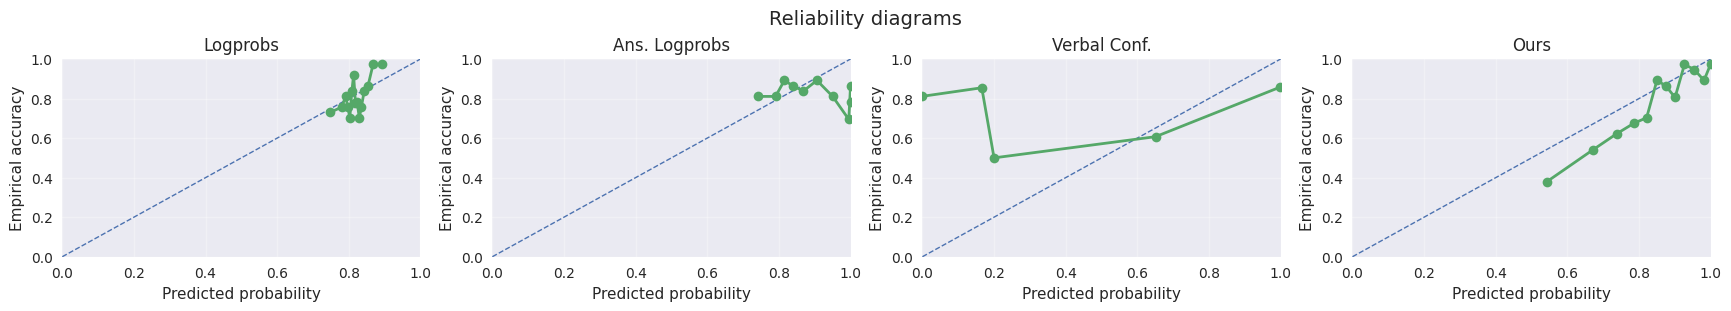

[status] running nvidia/Nemotron-Cascade-8B-Thinking
polymath nvidia/Nemotron-Cascade-8B-Thinking no rows 993


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,nvidia/Nemotron-Cascade-8B-Thinking,polymath,logprob,0.052767,0.064741,0.119976,0.345070,0.096892,0.657019,0.89094
1,nvidia/Nemotron-Cascade-8B-Thinking,polymath,ans_logprob,0.099329,0.104522,0.206846,1.035738,0.103189,0.734203,0.89094
2,nvidia/Nemotron-Cascade-8B-Thinking,polymath,oracle_sc,0.064044,0.086999,0.204815,0.469611,0.075972,0.840113,0.89094
3,nvidia/Nemotron-Cascade-8B-Thinking,polymath,ridge_clip,0.049050,0.066296,0.182786,0.448301,0.083804,0.758366,0.89094
4,nvidia/Nemotron-Cascade-8B-Thinking,polymath,split_isotonic_on_ridge,0.036718,0.039369,0.047343,0.356874,0.086888,0.748023,0.89094
5,nvidia/Nemotron-Cascade-8B-Thinking,polymath,split_isotonic_on_ridge_nrt,0.051752,0.073597,0.152124,0.296691,0.082883,0.810778,0.89094
6,nvidia/Nemotron-Cascade-8B-Thinking,polymath,verbal_conf,0.073890,0.074767,0.079108,1.122565,0.101974,0.636883,0.89094
7,nvidia/Nemotron-Cascade-8B-Thinking,polymath,blackbox_ridge_clip,0.054884,0.081112,0.241053,0.429967,0.082125,0.768188,0.89094
8,nvidia/Nemotron-Cascade-8B-Thinking,polymath,blackbox_split_isotonic_on_ridge,0.050000,0.054712,0.091502,0.342231,0.083534,0.761567,0.89094
9,nvidia/Nemotron-Cascade-8B-Thinking,polymath,blackbox_split_isotonic_on_ridge_nrt,0.054644,0.070648,0.142568,0.323000,0.085838,0.777459,0.89094


nvidia/Nemotron-Cascade-8B-Thinking polymath


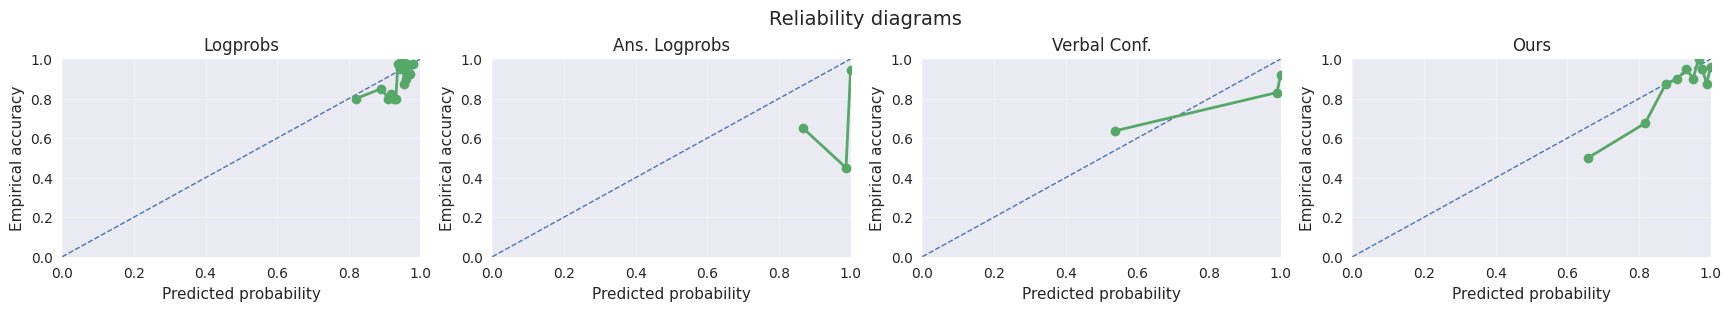

[status] running deepseek-ai/DeepSeek-R1-Distill-Llama-8B
polymath deepseek-ai/DeepSeek-R1-Distill-Llama-8B no rows 956


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,polymath,logprob,0.374117,0.410142,0.558267,1.113840,0.400198,0.487373,0.454704
1,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,polymath,ans_logprob,0.510295,0.552975,0.982771,4.483975,0.486333,0.768401,0.454704
2,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,polymath,oracle_sc,0.082038,0.105776,0.217500,0.516058,0.175516,0.824881,0.454704
3,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,polymath,ridge_clip,0.083048,0.104029,0.169137,0.591839,0.196231,0.780483,0.454704
4,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,polymath,split_isotonic_on_ridge,0.115992,0.135433,0.237443,0.601387,0.208341,0.773726,0.454704
5,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,polymath,split_isotonic_on_ridge_nrt,0.100781,0.118495,0.233175,0.582483,0.199977,0.783660,0.454704
6,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,polymath,verbal_conf,0.333057,0.368640,0.636364,2.186436,0.372150,0.569039,0.454704
7,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,polymath,blackbox_ridge_clip,0.091430,0.111094,0.209489,0.597272,0.191194,0.801317,0.454704
8,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,polymath,blackbox_split_isotonic_on_ridge,0.137861,0.146603,0.198052,0.594810,0.202272,0.799255,0.454704
9,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,polymath,blackbox_split_isotonic_on_ridge_nrt,0.118747,0.139905,0.285322,0.552275,0.186412,0.821411,0.454704


deepseek-ai/DeepSeek-R1-Distill-Llama-8B polymath


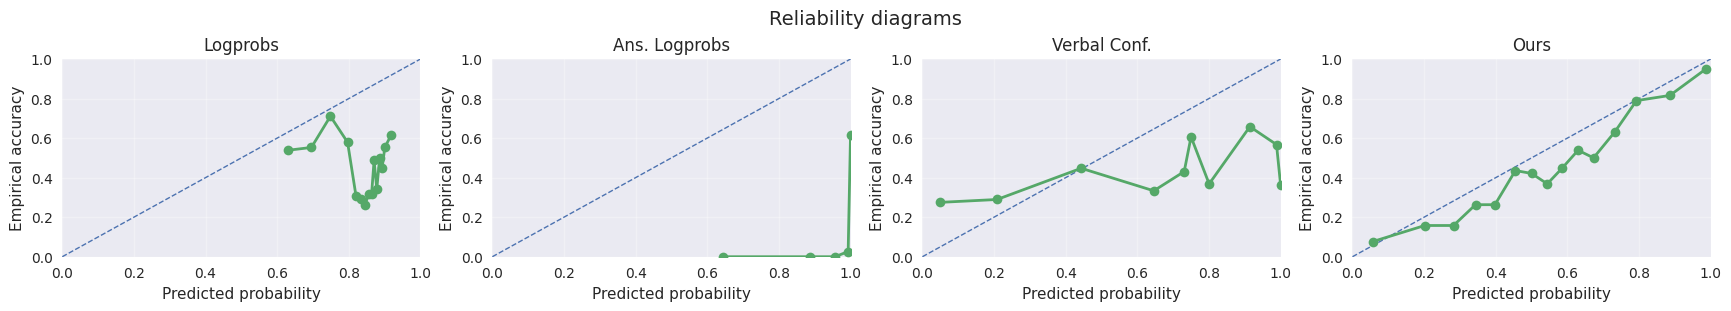

[status] running deepseek-ai/DeepSeek-R1-Distill-Qwen-7B
polymath deepseek-ai/DeepSeek-R1-Distill-Qwen-7B no rows 978


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,polymath,logprob,0.231500,0.258373,0.384917,0.876575,0.297240,0.497351,0.620102
1,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,polymath,ans_logprob,0.354929,0.486993,0.919635,2.086173,0.336361,0.889414,0.620102
2,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,polymath,oracle_sc,0.071925,0.090222,0.156170,0.427433,0.127555,0.903785,0.620102
3,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,polymath,ridge_clip,0.070159,0.080234,0.142341,0.620332,0.169952,0.815620,0.620102
4,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,polymath,split_isotonic_on_ridge,0.072299,0.085706,0.207257,0.528736,0.173363,0.810982,0.620102
5,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,polymath,split_isotonic_on_ridge_nrt,0.071301,0.080038,0.151381,0.527371,0.174362,0.812207,0.620102
6,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,polymath,verbal_conf,0.270098,0.289170,0.389831,2.464750,0.287970,0.699786,0.620102
7,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,polymath,blackbox_ridge_clip,0.049533,0.062943,0.140994,0.568211,0.165351,0.824096,0.620102
8,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,polymath,blackbox_split_isotonic_on_ridge,0.079167,0.124759,0.287722,0.526872,0.176667,0.821459,0.620102
9,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,polymath,blackbox_split_isotonic_on_ridge_nrt,0.082785,0.115929,0.246113,0.563075,0.183023,0.802259,0.620102


deepseek-ai/DeepSeek-R1-Distill-Qwen-7B polymath


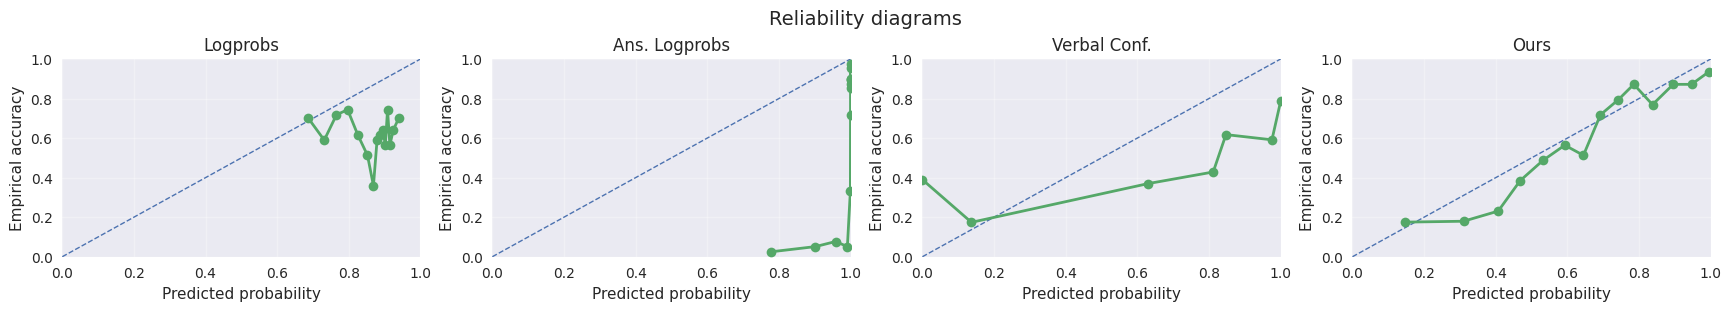

--- 1425.2165818214417 seconds ---
[status] running trivia_qa
[status] running Qwen/Qwen3-0.6B
trivia_qa Qwen/Qwen3-0.6B no rows 961


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-0.6B,trivia_qa,logprob,0.414585,0.421666,0.503145,0.864833,0.333093,0.639614,0.211438
1,Qwen/Qwen3-0.6B,trivia_qa,ans_logprob,0.732344,0.737904,0.833187,4.507026,0.708733,0.572690,0.211438
2,Qwen/Qwen3-0.6B,trivia_qa,oracle_sc,0.070433,0.082323,0.164828,0.425994,0.135642,0.797919,0.211438
3,Qwen/Qwen3-0.6B,trivia_qa,ridge_clip,0.129011,0.172214,0.456466,0.861216,0.192936,0.597847,0.211438
4,Qwen/Qwen3-0.6B,trivia_qa,split_isotonic_on_ridge,0.057533,0.077612,0.201066,0.516437,0.168233,0.598721,0.211438
5,Qwen/Qwen3-0.6B,trivia_qa,split_isotonic_on_ridge_nrt,0.072702,0.080441,0.227426,0.503597,0.162757,0.650180,0.211438
6,Qwen/Qwen3-0.6B,trivia_qa,verbal_conf,0.671109,0.701094,0.773543,8.727162,0.681104,0.536912,0.211438
7,Qwen/Qwen3-0.6B,trivia_qa,blackbox_ridge_clip,0.079550,0.094985,0.203177,0.541729,0.157213,0.701558,0.211438
8,Qwen/Qwen3-0.6B,trivia_qa,blackbox_split_isotonic_on_ridge,0.099556,0.108399,0.222523,0.503613,0.162199,0.693488,0.211438
9,Qwen/Qwen3-0.6B,trivia_qa,blackbox_split_isotonic_on_ridge_nrt,0.087860,0.107922,0.154396,0.505210,0.163566,0.683174,0.211438


Qwen/Qwen3-0.6B trivia_qa


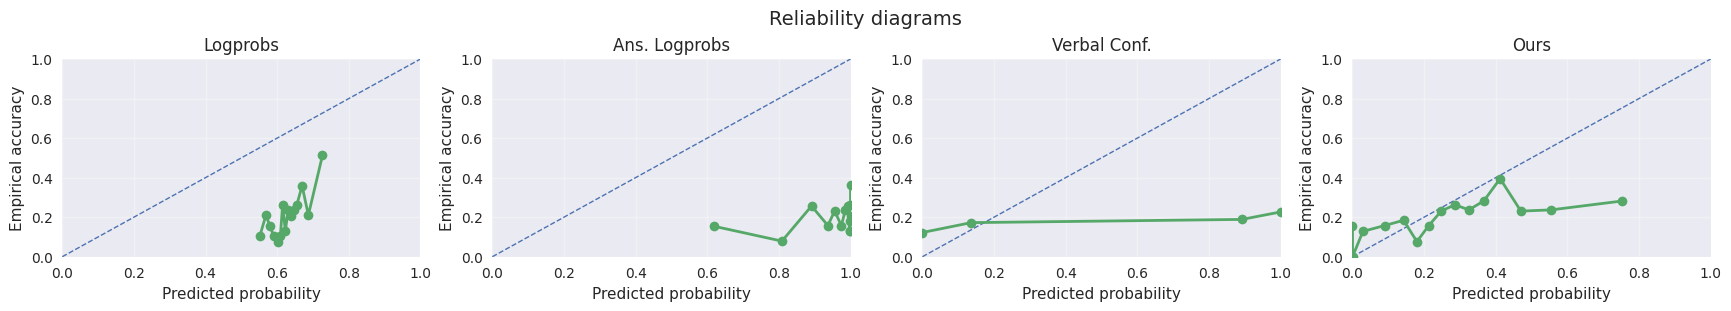

[status] running Qwen/Qwen3-1.7B
trivia_qa Qwen/Qwen3-1.7B no rows 996


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-1.7B,trivia_qa,logprob,0.407268,0.427235,0.546134,1.048509,0.397430,0.674942,0.396321
1,Qwen/Qwen3-1.7B,trivia_qa,ans_logprob,0.584614,0.589187,0.718699,5.679750,0.578786,0.544859,0.396321
2,Qwen/Qwen3-1.7B,trivia_qa,oracle_sc,0.083244,0.093311,0.174600,0.548490,0.166591,0.836361,0.396321
3,Qwen/Qwen3-1.7B,trivia_qa,ridge_clip,0.125978,0.141032,0.269545,0.865496,0.220121,0.729718,0.396321
4,Qwen/Qwen3-1.7B,trivia_qa,split_isotonic_on_ridge,0.103795,0.130242,0.295379,0.695958,0.223645,0.710643,0.396321
5,Qwen/Qwen3-1.7B,trivia_qa,split_isotonic_on_ridge_nrt,0.114387,0.149900,0.534440,0.712316,0.222293,0.726621,0.396321
6,Qwen/Qwen3-1.7B,trivia_qa,verbal_conf,0.463208,0.484328,0.588485,4.962472,0.468671,0.614742,0.396321
7,Qwen/Qwen3-1.7B,trivia_qa,blackbox_ridge_clip,0.094210,0.107448,0.200685,0.682534,0.208550,0.734820,0.396321
8,Qwen/Qwen3-1.7B,trivia_qa,blackbox_split_isotonic_on_ridge,0.075097,0.096647,0.152703,0.603574,0.206289,0.737228,0.396321
9,Qwen/Qwen3-1.7B,trivia_qa,blackbox_split_isotonic_on_ridge_nrt,0.081774,0.098886,0.165608,0.605916,0.207261,0.738712,0.396321


Qwen/Qwen3-1.7B trivia_qa


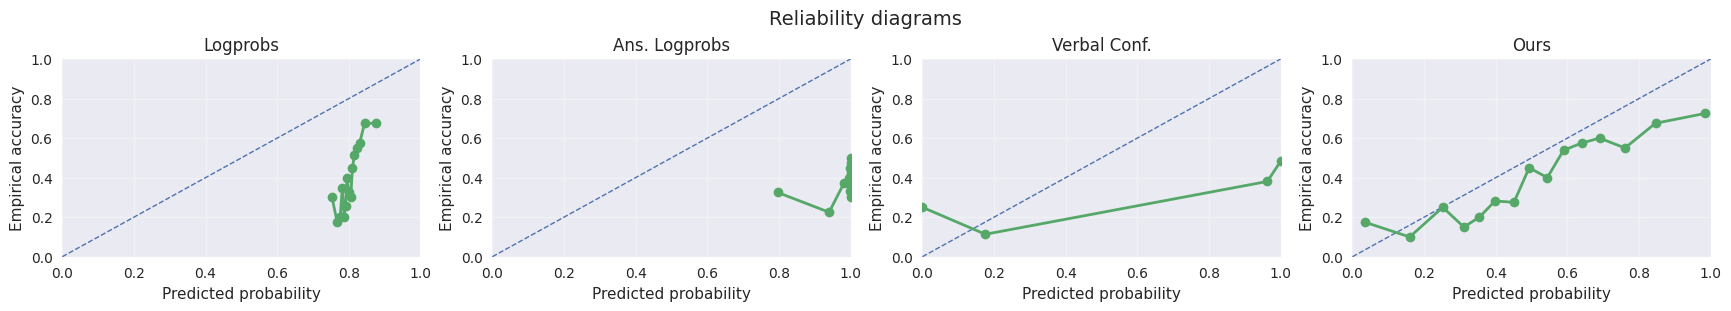

[status] running Qwen/Qwen3-4B-Thinking-2507
trivia_qa Qwen/Qwen3-4B-Thinking-2507 no rows 997


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-4B-Thinking-2507,trivia_qa,logprob,0.245737,0.279780,0.413571,0.747413,0.274881,0.737768,0.54591
1,Qwen/Qwen3-4B-Thinking-2507,trivia_qa,ans_logprob,0.390355,0.427889,0.677985,3.611958,0.415092,0.494856,0.54591
2,Qwen/Qwen3-4B-Thinking-2507,trivia_qa,oracle_sc,0.085409,0.092875,0.153725,0.509073,0.156660,0.856072,0.54591
3,Qwen/Qwen3-4B-Thinking-2507,trivia_qa,ridge_clip,0.057657,0.065985,0.140402,0.579564,0.182043,0.803236,0.54591
4,Qwen/Qwen3-4B-Thinking-2507,trivia_qa,split_isotonic_on_ridge,0.086066,0.102530,0.163667,0.564443,0.190727,0.798379,0.54591
5,Qwen/Qwen3-4B-Thinking-2507,trivia_qa,split_isotonic_on_ridge_nrt,0.110795,0.118123,0.168627,0.553048,0.185254,0.817014,0.54591
6,Qwen/Qwen3-4B-Thinking-2507,trivia_qa,verbal_conf,0.358811,0.389974,0.689552,1.974896,0.356052,0.704848,0.54591
7,Qwen/Qwen3-4B-Thinking-2507,trivia_qa,blackbox_ridge_clip,0.056600,0.068717,0.147480,0.616351,0.188378,0.786388,0.54591
8,Qwen/Qwen3-4B-Thinking-2507,trivia_qa,blackbox_split_isotonic_on_ridge,0.072346,0.083524,0.147056,0.572820,0.193697,0.782279,0.54591
9,Qwen/Qwen3-4B-Thinking-2507,trivia_qa,blackbox_split_isotonic_on_ridge_nrt,0.087341,0.104931,0.226261,0.573115,0.193762,0.786579,0.54591


Qwen/Qwen3-4B-Thinking-2507 trivia_qa


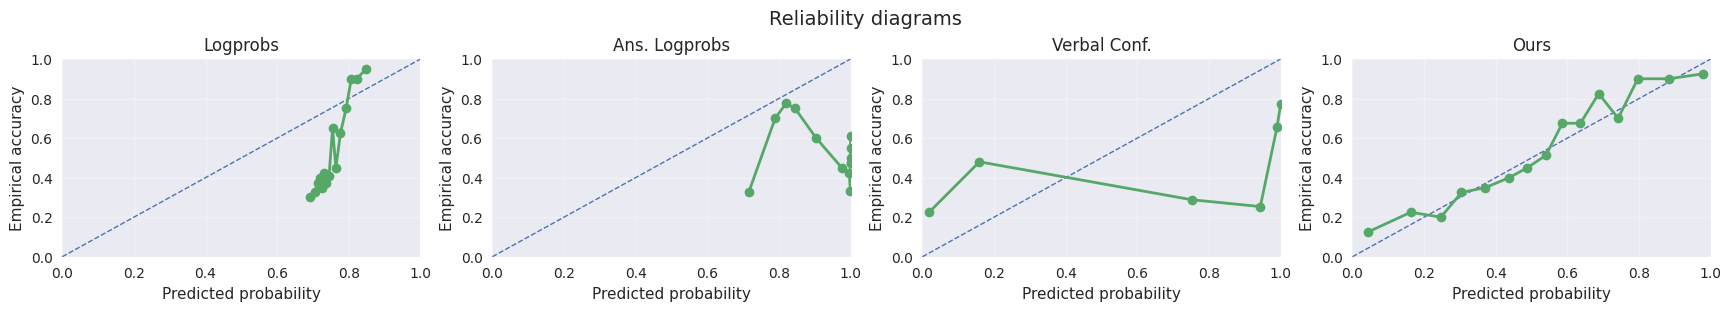

[status] running Qwen/Qwen3-8B
trivia_qa Qwen/Qwen3-8B no rows 985


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-8B,trivia_qa,logprob,0.170577,0.222258,0.433512,0.696107,0.246917,0.724445,0.642978
1,Qwen/Qwen3-8B,trivia_qa,ans_logprob,0.333420,0.342622,0.479994,3.357929,0.337533,0.594537,0.642978
2,Qwen/Qwen3-8B,trivia_qa,oracle_sc,0.036954,0.048295,0.124694,0.503320,0.143390,0.863295,0.642978
3,Qwen/Qwen3-8B,trivia_qa,ridge_clip,0.091847,0.105933,0.193411,0.605400,0.150695,0.856311,0.642978
4,Qwen/Qwen3-8B,trivia_qa,split_isotonic_on_ridge,0.097878,0.116452,0.303539,0.490720,0.158930,0.850437,0.642978
5,Qwen/Qwen3-8B,trivia_qa,split_isotonic_on_ridge_nrt,0.108424,0.132990,0.285213,0.472482,0.151931,0.868215,0.642978
6,Qwen/Qwen3-8B,trivia_qa,verbal_conf,0.224467,0.264186,0.440616,1.017110,0.242665,0.779565,0.642978
7,Qwen/Qwen3-8B,trivia_qa,blackbox_ridge_clip,0.064682,0.075322,0.174844,0.569575,0.155864,0.840203,0.642978
8,Qwen/Qwen3-8B,trivia_qa,blackbox_split_isotonic_on_ridge,0.087602,0.107757,0.197785,0.510010,0.167628,0.822163,0.642978
9,Qwen/Qwen3-8B,trivia_qa,blackbox_split_isotonic_on_ridge_nrt,0.109946,0.155463,0.654287,0.509455,0.167031,0.839025,0.642978


Qwen/Qwen3-8B trivia_qa


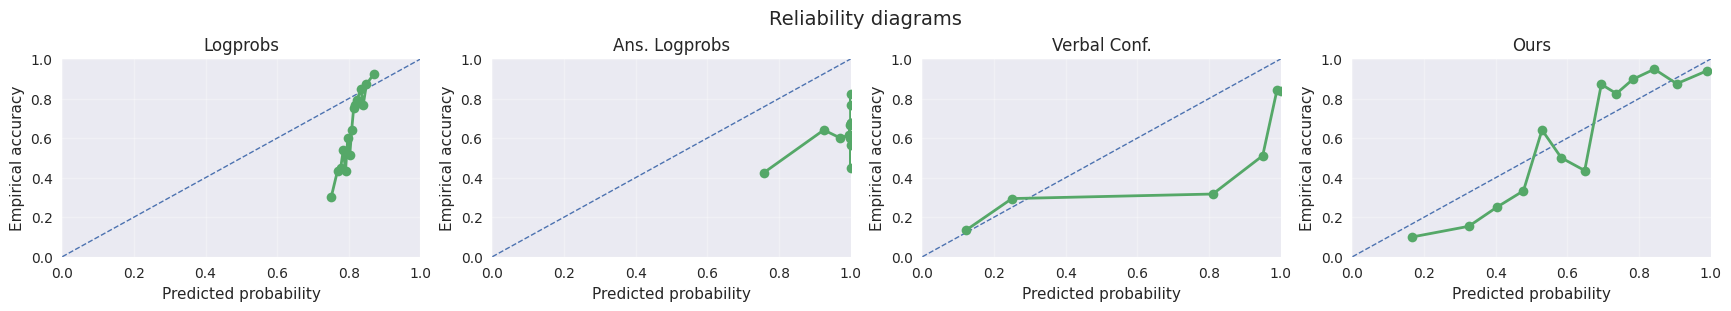

[status] running Qwen/Qwen3-14B
trivia_qa Qwen/Qwen3-14B no rows 999


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-14B,trivia_qa,logprob,0.148570,0.204875,0.500395,0.564166,0.192931,0.805464,0.715
1,Qwen/Qwen3-14B,trivia_qa,ans_logprob,0.257595,0.269105,0.459999,2.545734,0.266375,0.604425,0.715
2,Qwen/Qwen3-14B,trivia_qa,oracle_sc,0.044017,0.058608,0.129273,0.389694,0.117610,0.891186,0.715
3,Qwen/Qwen3-14B,trivia_qa,ridge_clip,0.045944,0.054041,0.113603,0.587273,0.151354,0.806193,0.715
4,Qwen/Qwen3-14B,trivia_qa,split_isotonic_on_ridge,0.054747,0.063398,0.207117,0.481474,0.154207,0.798784,0.715
5,Qwen/Qwen3-14B,trivia_qa,split_isotonic_on_ridge_nrt,0.036790,0.060914,0.211134,0.521093,0.170979,0.735595,0.715
6,Qwen/Qwen3-14B,trivia_qa,verbal_conf,0.170317,0.192322,0.295390,0.787634,0.196399,0.766273,0.715
7,Qwen/Qwen3-14B,trivia_qa,blackbox_ridge_clip,0.049982,0.056494,0.081325,0.564465,0.166853,0.762756,0.715
8,Qwen/Qwen3-14B,trivia_qa,blackbox_split_isotonic_on_ridge,0.063580,0.083123,0.256704,0.511708,0.169878,0.761863,0.715
9,Qwen/Qwen3-14B,trivia_qa,blackbox_split_isotonic_on_ridge_nrt,0.057535,0.077216,0.152409,0.525898,0.174983,0.742370,0.715


Qwen/Qwen3-14B trivia_qa


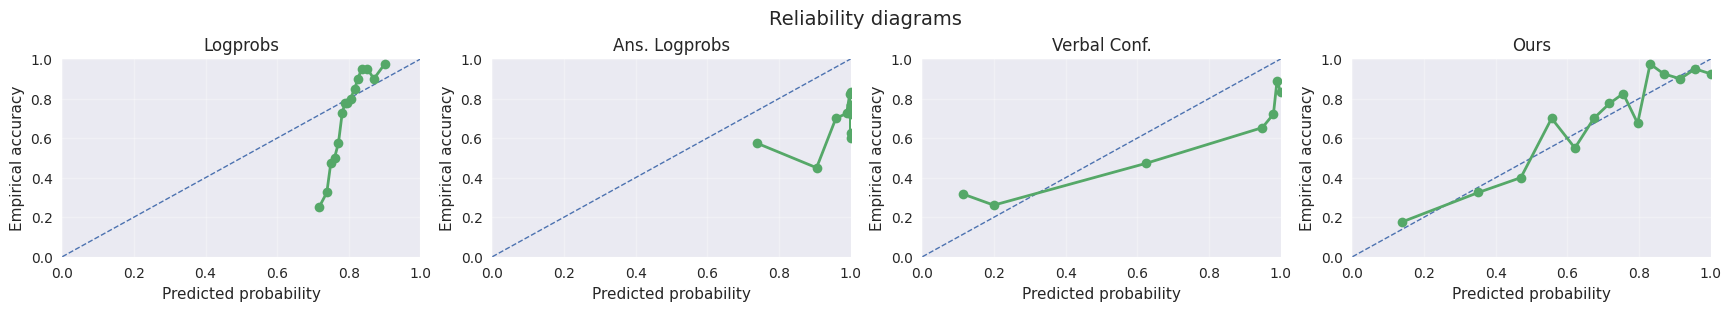

[status] running nvidia/OpenReasoning-Nemotron-7B
[status] running nvidia/Nemotron-Cascade-8B-Thinking
trivia_qa nvidia/Nemotron-Cascade-8B-Thinking no rows 999


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,nvidia/Nemotron-Cascade-8B-Thinking,trivia_qa,logprob,0.350138,0.372379,0.552915,1.031077,0.363774,0.664837,0.523333
1,nvidia/Nemotron-Cascade-8B-Thinking,trivia_qa,ans_logprob,0.463595,0.468417,0.539951,4.848009,0.467545,0.518162,0.523333
2,nvidia/Nemotron-Cascade-8B-Thinking,trivia_qa,oracle_sc,0.069017,0.085597,0.191087,0.519732,0.157133,0.855675,0.523333
3,nvidia/Nemotron-Cascade-8B-Thinking,trivia_qa,ridge_clip,0.053420,0.067368,0.167438,0.632049,0.196623,0.767455,0.523333
4,nvidia/Nemotron-Cascade-8B-Thinking,trivia_qa,split_isotonic_on_ridge,0.045797,0.073753,0.168438,0.585530,0.198746,0.764487,0.523333
5,nvidia/Nemotron-Cascade-8B-Thinking,trivia_qa,split_isotonic_on_ridge_nrt,0.085140,0.099169,0.165532,0.559634,0.188165,0.804263,0.523333
6,nvidia/Nemotron-Cascade-8B-Thinking,trivia_qa,verbal_conf,0.382464,0.388015,0.980000,2.786793,0.384553,0.632639,0.523333
7,nvidia/Nemotron-Cascade-8B-Thinking,trivia_qa,blackbox_ridge_clip,0.035018,0.042567,0.076175,0.625463,0.201308,0.756241,0.523333
8,nvidia/Nemotron-Cascade-8B-Thinking,trivia_qa,blackbox_split_isotonic_on_ridge,0.040620,0.047342,0.125556,0.596186,0.205003,0.744605,0.523333
9,nvidia/Nemotron-Cascade-8B-Thinking,trivia_qa,blackbox_split_isotonic_on_ridge_nrt,0.061300,0.081037,0.177253,0.595850,0.204713,0.752656,0.523333


nvidia/Nemotron-Cascade-8B-Thinking trivia_qa


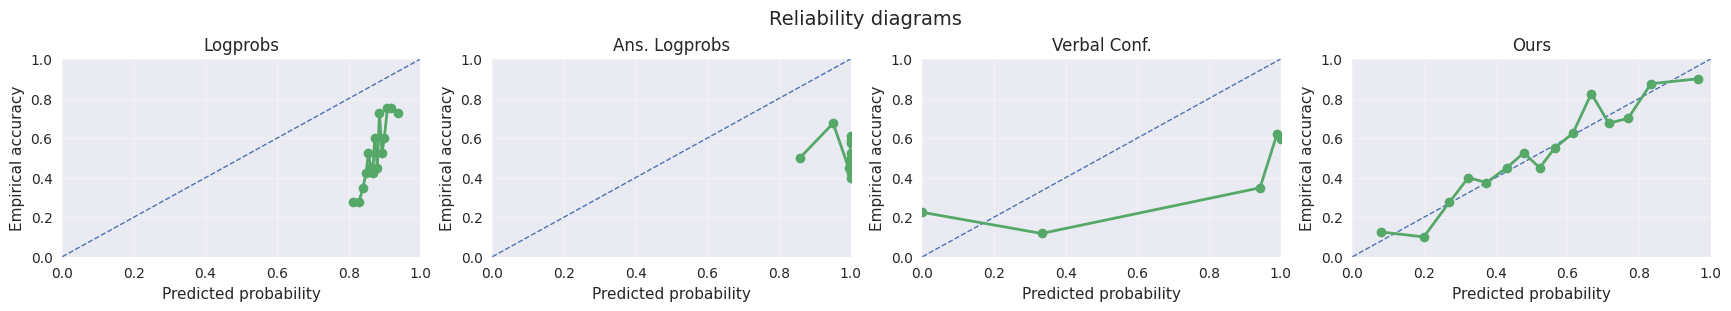

[status] running deepseek-ai/DeepSeek-R1-Distill-Llama-8B
[status] running deepseek-ai/DeepSeek-R1-Distill-Qwen-7B
--- 932.7133231163025 seconds ---
[status] running sciq
[status] running Qwen/Qwen3-0.6B
sciq Qwen/Qwen3-0.6B no rows 970


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-0.6B,sciq,logprob,0.249902,0.265239,0.355329,0.778169,0.291103,0.631567,0.391753
1,Qwen/Qwen3-0.6B,sciq,ans_logprob,0.512964,0.523753,0.708145,2.270086,0.509504,0.528236,0.391753
2,Qwen/Qwen3-0.6B,sciq,oracle_sc,0.061529,0.079514,0.189783,0.593504,0.204189,0.737524,0.391753
3,Qwen/Qwen3-0.6B,sciq,ridge_clip,0.150452,0.184050,0.345665,1.127375,0.265164,0.592582,0.391753
4,Qwen/Qwen3-0.6B,sciq,split_isotonic_on_ridge,0.026365,0.038014,0.128105,0.669377,0.236182,0.587719,0.391753
5,Qwen/Qwen3-0.6B,sciq,split_isotonic_on_ridge_nrt,0.051527,0.089476,0.242857,0.664913,0.236029,0.585625,0.391753
6,Qwen/Qwen3-0.6B,sciq,verbal_conf,0.557784,0.562840,0.586957,7.366954,0.571027,0.540050,0.391753
7,Qwen/Qwen3-0.6B,sciq,blackbox_ridge_clip,0.122860,0.168524,0.395607,0.734026,0.244187,0.604123,0.391753
8,Qwen/Qwen3-0.6B,sciq,blackbox_split_isotonic_on_ridge,0.089148,0.099794,0.156154,0.655016,0.231688,0.600561,0.391753
9,Qwen/Qwen3-0.6B,sciq,blackbox_split_isotonic_on_ridge_nrt,0.040592,0.058341,0.129025,0.644425,0.226508,0.633016,0.391753


Qwen/Qwen3-0.6B sciq


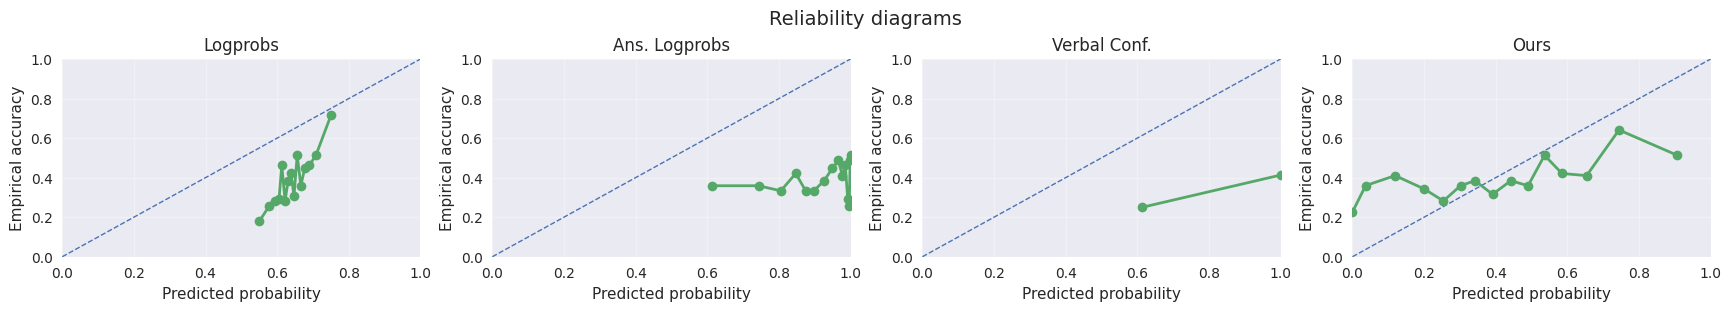

[status] running Qwen/Qwen3-1.7B
sciq Qwen/Qwen3-1.7B no rows 1000


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-1.7B,sciq,logprob,0.226841,0.267234,0.441259,0.775871,0.279217,0.694375,0.6
1,Qwen/Qwen3-1.7B,sciq,ans_logprob,0.355396,0.372775,0.556449,2.417966,0.373020,0.549207,0.6
2,Qwen/Qwen3-1.7B,sciq,oracle_sc,0.083000,0.093057,0.150400,0.627828,0.198103,0.747488,0.6
3,Qwen/Qwen3-1.7B,sciq,ridge_clip,0.100678,0.138194,0.306364,0.920640,0.233251,0.671979,0.6
4,Qwen/Qwen3-1.7B,sciq,split_isotonic_on_ridge,0.060423,0.087951,0.273073,0.682923,0.223067,0.669925,0.6
5,Qwen/Qwen3-1.7B,sciq,split_isotonic_on_ridge_nrt,0.047215,0.057201,0.116855,0.632004,0.220369,0.664959,0.6
6,Qwen/Qwen3-1.7B,sciq,verbal_conf,0.342250,0.353877,0.423984,3.178709,0.362798,0.616759,0.6
7,Qwen/Qwen3-1.7B,sciq,blackbox_ridge_clip,0.074873,0.093805,0.164872,0.749224,0.220580,0.688073,0.6
8,Qwen/Qwen3-1.7B,sciq,blackbox_split_isotonic_on_ridge,0.044475,0.066929,0.160449,0.631914,0.217900,0.679253,0.6
9,Qwen/Qwen3-1.7B,sciq,blackbox_split_isotonic_on_ridge_nrt,0.050835,0.057739,0.136304,0.628352,0.217568,0.671696,0.6


Qwen/Qwen3-1.7B sciq


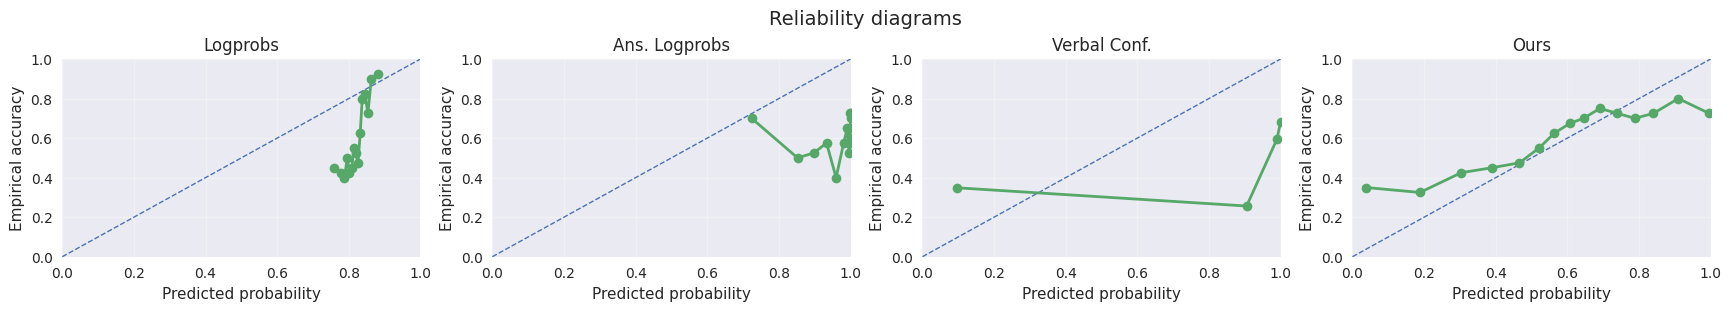

[status] running Qwen/Qwen3-4B-Thinking-2507
sciq Qwen/Qwen3-4B-Thinking-2507 no rows 1000


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-4B-Thinking-2507,sciq,logprob,0.170070,0.206541,0.383680,0.710617,0.250571,0.652384,0.648333
1,Qwen/Qwen3-4B-Thinking-2507,sciq,ans_logprob,0.221830,0.241030,0.359994,1.373050,0.275574,0.575634,0.648333
2,Qwen/Qwen3-4B-Thinking-2507,sciq,oracle_sc,0.086367,0.108816,0.242157,0.638612,0.203623,0.707623,0.648333
3,Qwen/Qwen3-4B-Thinking-2507,sciq,ridge_clip,0.090871,0.114385,0.230272,0.721494,0.213608,0.664232,0.648333
4,Qwen/Qwen3-4B-Thinking-2507,sciq,split_isotonic_on_ridge,0.085054,0.099424,0.172741,0.610722,0.210517,0.665828,0.648333
5,Qwen/Qwen3-4B-Thinking-2507,sciq,split_isotonic_on_ridge_nrt,0.089554,0.101599,0.187463,0.617106,0.213487,0.654595,0.648333
6,Qwen/Qwen3-4B-Thinking-2507,sciq,verbal_conf,0.330946,0.345434,0.526400,1.767747,0.337409,0.585984,0.648333
7,Qwen/Qwen3-4B-Thinking-2507,sciq,blackbox_ridge_clip,0.081583,0.100924,0.213088,0.722663,0.217271,0.644014,0.648333
8,Qwen/Qwen3-4B-Thinking-2507,sciq,blackbox_split_isotonic_on_ridge,0.085706,0.105854,0.254615,0.638086,0.222369,0.637039,0.648333
9,Qwen/Qwen3-4B-Thinking-2507,sciq,blackbox_split_isotonic_on_ridge_nrt,0.106311,0.114828,0.275030,0.638382,0.222811,0.645969,0.648333


Qwen/Qwen3-4B-Thinking-2507 sciq


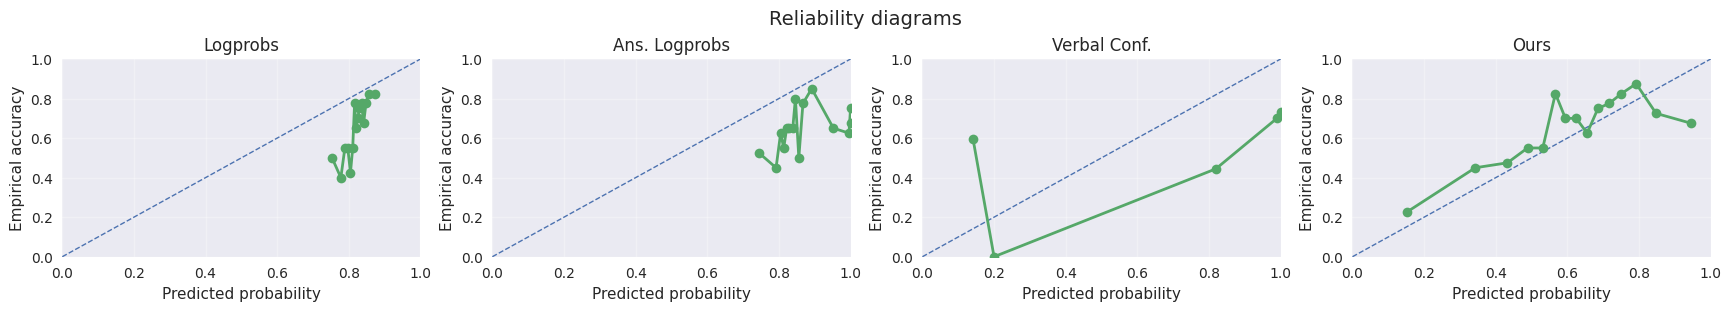

[status] running Qwen/Qwen3-8B
sciq Qwen/Qwen3-8B no rows 1000


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-8B,sciq,logprob,0.158074,0.174684,0.284180,0.700188,0.246560,0.621922,0.653333
1,Qwen/Qwen3-8B,sciq,ans_logprob,0.295380,0.308219,0.499415,1.763060,0.310394,0.593928,0.653333
2,Qwen/Qwen3-8B,sciq,oracle_sc,0.097967,0.114090,0.195152,0.815066,0.199901,0.734154,0.653333
3,Qwen/Qwen3-8B,sciq,ridge_clip,0.092752,0.109050,0.179277,0.825543,0.207670,0.703916,0.653333
4,Qwen/Qwen3-8B,sciq,split_isotonic_on_ridge,0.080886,0.094402,0.214834,0.607815,0.206285,0.707221,0.653333
5,Qwen/Qwen3-8B,sciq,split_isotonic_on_ridge_nrt,0.057169,0.066901,0.122545,0.581759,0.196429,0.721736,0.653333
6,Qwen/Qwen3-8B,sciq,verbal_conf,0.283600,0.310175,0.429249,1.222502,0.298194,0.689027,0.653333
7,Qwen/Qwen3-8B,sciq,blackbox_ridge_clip,0.070421,0.092869,0.199838,0.817762,0.211844,0.682833,0.653333
8,Qwen/Qwen3-8B,sciq,blackbox_split_isotonic_on_ridge,0.058991,0.082477,0.215215,0.673113,0.209312,0.679675,0.653333
9,Qwen/Qwen3-8B,sciq,blackbox_split_isotonic_on_ridge_nrt,0.051306,0.061292,0.159020,0.590974,0.202167,0.693779,0.653333


Qwen/Qwen3-8B sciq


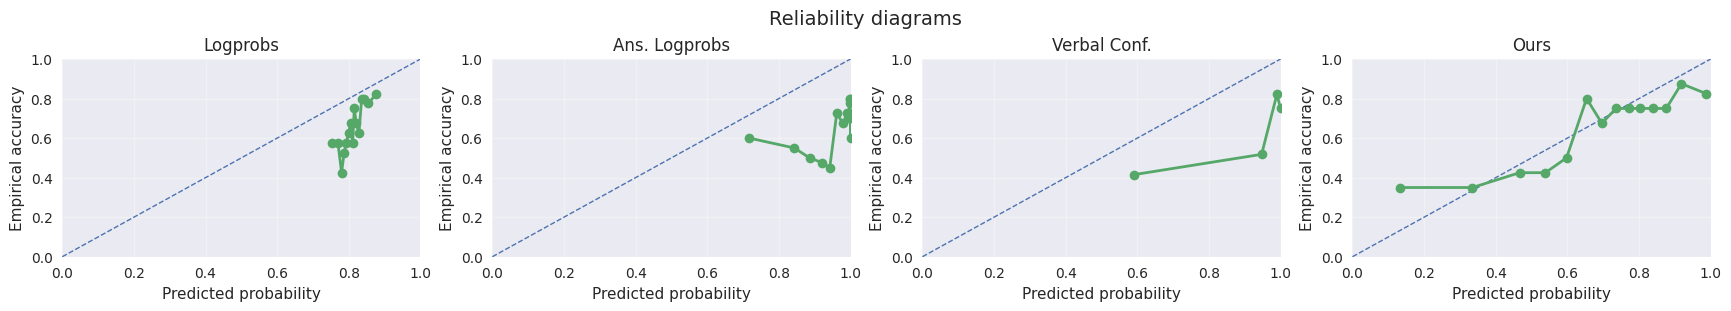

[status] running Qwen/Qwen3-14B
sciq Qwen/Qwen3-14B no rows 1000


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-14B,sciq,logprob,0.126252,0.146207,0.253312,0.629180,0.217424,0.647379,0.693333
1,Qwen/Qwen3-14B,sciq,ans_logprob,0.246267,0.261367,0.426399,1.407013,0.273192,0.582632,0.693333
2,Qwen/Qwen3-14B,sciq,oracle_sc,0.123567,0.148946,0.253333,0.800154,0.203349,0.697422,0.693333
3,Qwen/Qwen3-14B,sciq,ridge_clip,0.058155,0.086684,0.240113,0.708087,0.187732,0.729933,0.693333
4,Qwen/Qwen3-14B,sciq,split_isotonic_on_ridge,0.048558,0.073921,0.218889,0.565146,0.185601,0.730488,0.693333
5,Qwen/Qwen3-14B,sciq,split_isotonic_on_ridge_nrt,0.053491,0.069635,0.732007,0.555754,0.186479,0.713609,0.693333
6,Qwen/Qwen3-14B,sciq,verbal_conf,0.244600,0.257372,0.384937,1.055369,0.268605,0.640566,0.693333
7,Qwen/Qwen3-14B,sciq,blackbox_ridge_clip,0.078337,0.095461,0.176679,0.678910,0.195519,0.697893,0.693333
8,Qwen/Qwen3-14B,sciq,blackbox_split_isotonic_on_ridge,0.045943,0.056653,0.222631,0.572332,0.191690,0.693804,0.693333
9,Qwen/Qwen3-14B,sciq,blackbox_split_isotonic_on_ridge_nrt,0.026797,0.038058,0.133273,0.560185,0.188519,0.704582,0.693333


Qwen/Qwen3-14B sciq


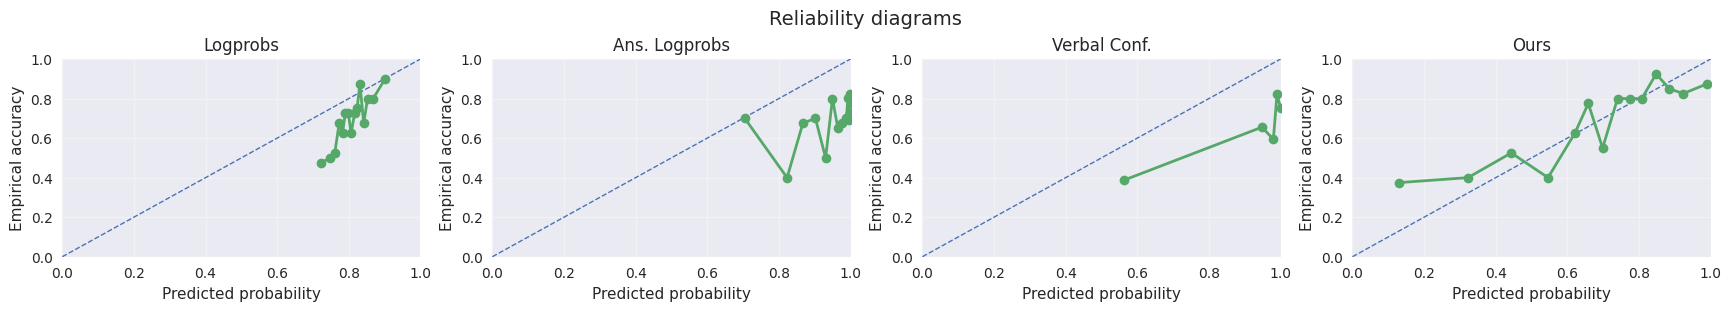

[status] running nvidia/OpenReasoning-Nemotron-7B
[status] running nvidia/Nemotron-Cascade-8B-Thinking
sciq nvidia/Nemotron-Cascade-8B-Thinking no rows 999


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,nvidia/Nemotron-Cascade-8B-Thinking,sciq,logprob,0.235045,0.252055,0.404789,0.821187,0.274619,0.640597,0.66
1,nvidia/Nemotron-Cascade-8B-Thinking,sciq,ans_logprob,0.310195,0.331777,0.544147,2.181321,0.311162,0.666580,0.66
2,nvidia/Nemotron-Cascade-8B-Thinking,sciq,oracle_sc,0.092883,0.103755,0.162235,0.794931,0.194051,0.724630,0.66
3,nvidia/Nemotron-Cascade-8B-Thinking,sciq,ridge_clip,0.051242,0.064182,0.138611,0.702342,0.192838,0.722191,0.66
4,nvidia/Nemotron-Cascade-8B-Thinking,sciq,split_isotonic_on_ridge,0.054806,0.060355,0.130911,0.584058,0.192905,0.722922,0.66
5,nvidia/Nemotron-Cascade-8B-Thinking,sciq,split_isotonic_on_ridge_nrt,0.036492,0.050992,0.137585,0.573138,0.193196,0.719041,0.66
6,nvidia/Nemotron-Cascade-8B-Thinking,sciq,verbal_conf,0.288867,0.292274,0.351834,1.710076,0.306893,0.630496,0.66
7,nvidia/Nemotron-Cascade-8B-Thinking,sciq,blackbox_ridge_clip,0.097271,0.106257,0.176245,0.766520,0.215093,0.658781,0.66
8,nvidia/Nemotron-Cascade-8B-Thinking,sciq,blackbox_split_isotonic_on_ridge,0.053610,0.071578,0.138527,0.614733,0.209923,0.651843,0.66
9,nvidia/Nemotron-Cascade-8B-Thinking,sciq,blackbox_split_isotonic_on_ridge_nrt,0.044285,0.077229,0.203315,0.594858,0.201876,0.698214,0.66


nvidia/Nemotron-Cascade-8B-Thinking sciq


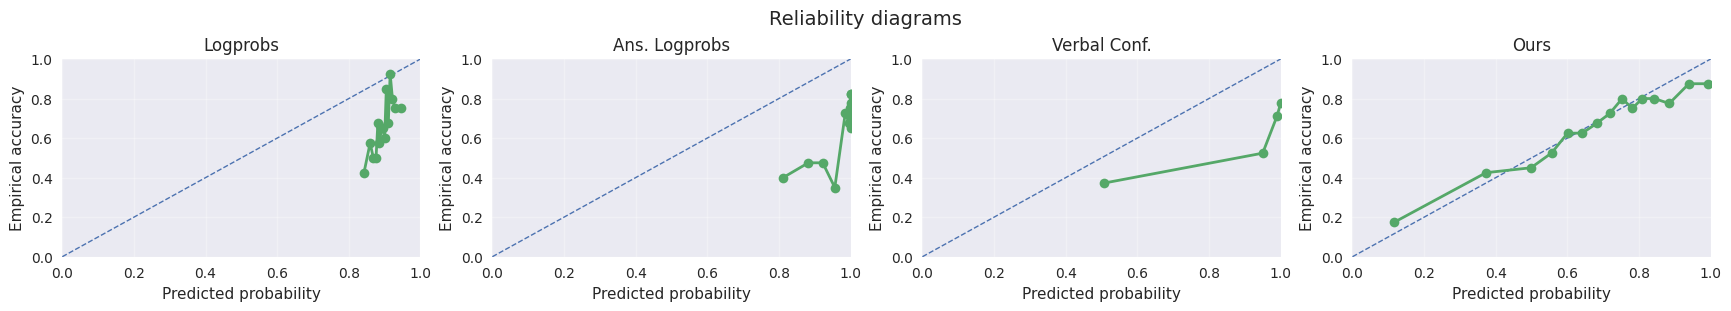

[status] running deepseek-ai/DeepSeek-R1-Distill-Llama-8B
[status] running deepseek-ai/DeepSeek-R1-Distill-Qwen-7B
--- 864.4225559234619 seconds ---
[status] running webq
[status] running Qwen/Qwen3-0.6B
webq Qwen/Qwen3-0.6B no rows 582


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-0.6B,webq,logprob,0.417997,0.422292,0.514817,0.863644,0.332772,0.579796,0.2
1,Qwen/Qwen3-0.6B,webq,ans_logprob,0.714288,0.720464,0.854754,3.700893,0.671165,0.603571,0.2
2,Qwen/Qwen3-0.6B,webq,oracle_sc,0.129229,0.165982,0.305000,0.538086,0.178909,0.620281,0.2
3,Qwen/Qwen3-0.6B,webq,ridge_clip,0.165025,0.217358,0.495155,0.804577,0.205627,0.578163,0.2
4,Qwen/Qwen3-0.6B,webq,split_isotonic_on_ridge,0.124409,0.133233,0.282819,0.538271,0.176321,0.575893,0.2
5,Qwen/Qwen3-0.6B,webq,split_isotonic_on_ridge_nrt,0.118911,0.137729,0.259346,0.539899,0.176656,0.531964,0.2
6,Qwen/Qwen3-0.6B,webq,verbal_conf,0.683429,0.711957,0.787072,8.707434,0.687823,0.532934,0.2
7,Qwen/Qwen3-0.6B,webq,blackbox_ridge_clip,0.144002,0.184716,0.405509,0.568911,0.188340,0.545102,0.2
8,Qwen/Qwen3-0.6B,webq,blackbox_split_isotonic_on_ridge,0.115503,0.118775,0.160474,0.534125,0.173668,0.523469,0.2
9,Qwen/Qwen3-0.6B,webq,blackbox_split_isotonic_on_ridge_nrt,0.127670,0.141668,0.357548,0.542830,0.177367,0.452985,0.2


Qwen/Qwen3-0.6B webq


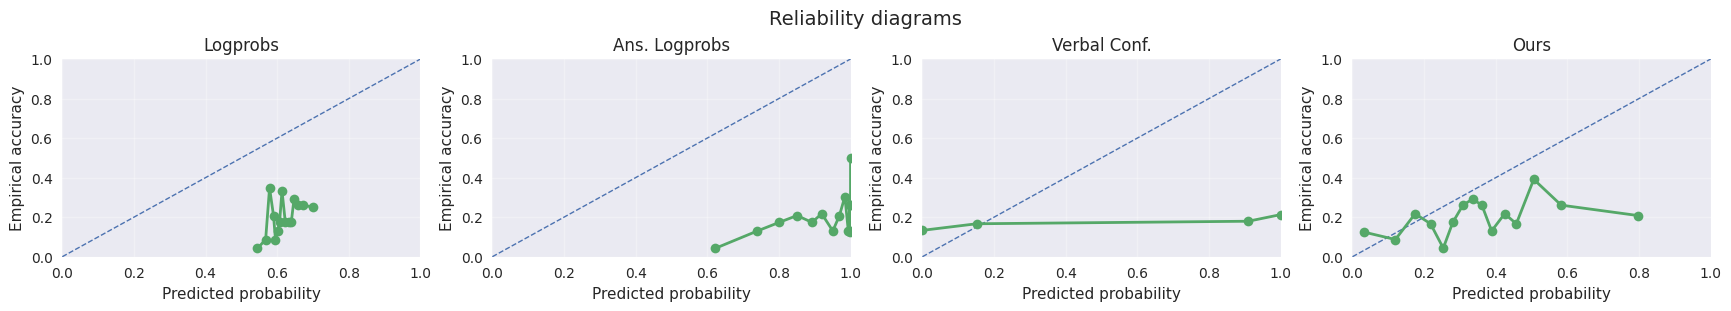

[status] running Qwen/Qwen3-1.7B
webq Qwen/Qwen3-1.7B no rows 986


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-1.7B,webq,logprob,0.457568,0.461741,0.578507,1.139098,0.434000,0.534158,0.341216
1,Qwen/Qwen3-1.7B,webq,ans_logprob,0.619642,0.624431,0.759998,4.645061,0.609771,0.518666,0.341216
2,Qwen/Qwen3-1.7B,webq,oracle_sc,0.142432,0.191195,0.402500,0.831254,0.241557,0.591787,0.341216
3,Qwen/Qwen3-1.7B,webq,ridge_clip,0.128556,0.150059,0.271864,0.951424,0.238539,0.597525,0.341216
4,Qwen/Qwen3-1.7B,webq,split_isotonic_on_ridge,0.084820,0.108127,0.181921,0.667786,0.228954,0.595449,0.341216
5,Qwen/Qwen3-1.7B,webq,split_isotonic_on_ridge_nrt,0.108831,0.137345,0.238006,0.694941,0.237570,0.551657,0.341216
6,Qwen/Qwen3-1.7B,webq,verbal_conf,0.492483,0.530596,0.630350,4.935760,0.509194,0.572918,0.341216
7,Qwen/Qwen3-1.7B,webq,blackbox_ridge_clip,0.133437,0.161398,0.277778,0.992761,0.237857,0.594117,0.341216
8,Qwen/Qwen3-1.7B,webq,blackbox_split_isotonic_on_ridge,0.103166,0.118505,0.293291,0.674748,0.227551,0.599765,0.341216
9,Qwen/Qwen3-1.7B,webq,blackbox_split_isotonic_on_ridge_nrt,0.111386,0.135394,0.287281,0.703294,0.239206,0.552564,0.341216


Qwen/Qwen3-1.7B webq


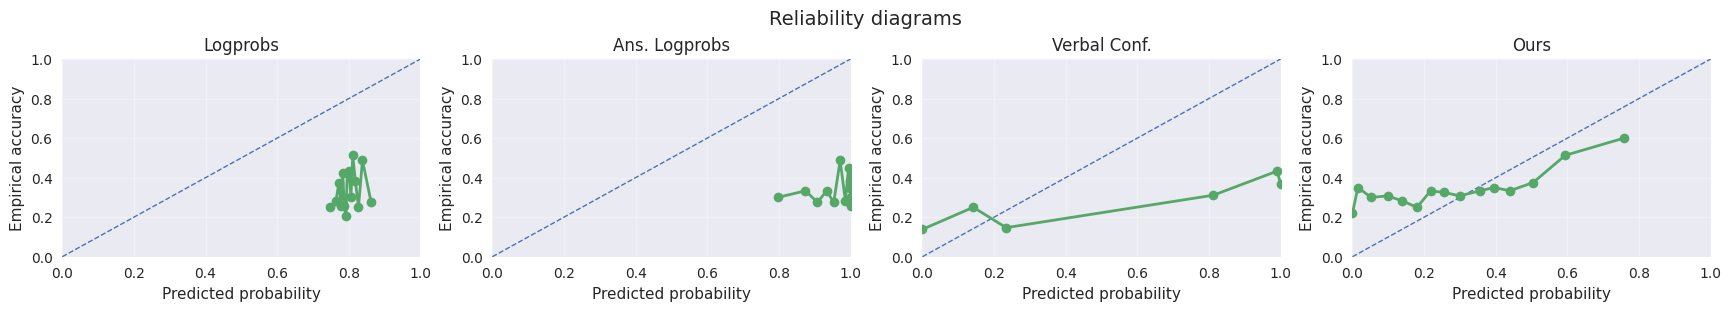

[status] running Qwen/Qwen3-4B-Thinking-2507
webq Qwen/Qwen3-4B-Thinking-2507 no rows 1000


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-4B-Thinking-2507,webq,logprob,0.349552,0.367277,0.521816,0.953870,0.360908,0.637336,0.43
1,Qwen/Qwen3-4B-Thinking-2507,webq,ans_logprob,0.439769,0.464000,0.640000,2.471321,0.451680,0.502505,0.43
2,Qwen/Qwen3-4B-Thinking-2507,webq,oracle_sc,0.149967,0.185269,0.380182,0.770604,0.243731,0.669517,0.43
3,Qwen/Qwen3-4B-Thinking-2507,webq,ridge_clip,0.119804,0.156256,0.310345,1.042359,0.245354,0.652636,0.43
4,Qwen/Qwen3-4B-Thinking-2507,webq,split_isotonic_on_ridge,0.090789,0.112125,0.179218,0.668858,0.233551,0.650647,0.43
5,Qwen/Qwen3-4B-Thinking-2507,webq,split_isotonic_on_ridge_nrt,0.078507,0.101671,0.283333,0.682358,0.237180,0.646176,0.43
6,Qwen/Qwen3-4B-Thinking-2507,webq,verbal_conf,0.417755,0.455737,0.626403,2.301895,0.423041,0.689752,0.43
7,Qwen/Qwen3-4B-Thinking-2507,webq,blackbox_ridge_clip,0.135935,0.167849,0.282626,0.988547,0.255323,0.630321,0.43
8,Qwen/Qwen3-4B-Thinking-2507,webq,blackbox_split_isotonic_on_ridge,0.105150,0.128230,0.248250,0.726912,0.250742,0.612567,0.43
9,Qwen/Qwen3-4B-Thinking-2507,webq,blackbox_split_isotonic_on_ridge_nrt,0.099186,0.112038,0.236872,0.702805,0.242002,0.625017,0.43


Qwen/Qwen3-4B-Thinking-2507 webq


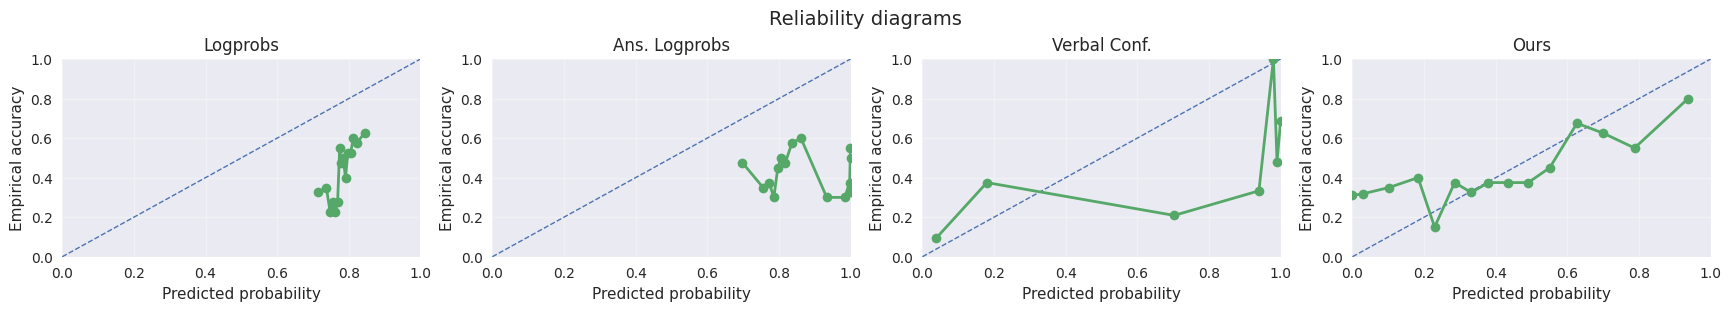

[status] running Qwen/Qwen3-8B
webq Qwen/Qwen3-8B no rows 993


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-8B,webq,logprob,0.375733,0.386569,0.513470,1.027705,0.383416,0.599059,0.441275
1,Qwen/Qwen3-8B,webq,ans_logprob,0.509994,0.517961,0.675841,3.387568,0.499091,0.623243,0.441275
2,Qwen/Qwen3-8B,webq,oracle_sc,0.141007,0.164880,0.309608,0.818609,0.237779,0.693808,0.441275
3,Qwen/Qwen3-8B,webq,ridge_clip,0.146047,0.168029,0.276697,1.000555,0.250439,0.661317,0.441275
4,Qwen/Qwen3-8B,webq,split_isotonic_on_ridge,0.124022,0.150241,0.234990,0.717018,0.249725,0.656299,0.441275
5,Qwen/Qwen3-8B,webq,split_isotonic_on_ridge_nrt,0.128029,0.145109,0.221227,0.695120,0.239321,0.673934,0.441275
6,Qwen/Qwen3-8B,webq,verbal_conf,0.430453,0.450960,0.841176,1.892916,0.440859,0.639583,0.441275
7,Qwen/Qwen3-8B,webq,blackbox_ridge_clip,0.136832,0.173925,0.311314,1.005067,0.261319,0.638601,0.441275
8,Qwen/Qwen3-8B,webq,blackbox_split_isotonic_on_ridge,0.134836,0.157821,0.307189,0.761223,0.253259,0.640450,0.441275
9,Qwen/Qwen3-8B,webq,blackbox_split_isotonic_on_ridge_nrt,0.107547,0.129881,0.218593,0.767803,0.246267,0.645138,0.441275


Qwen/Qwen3-8B webq


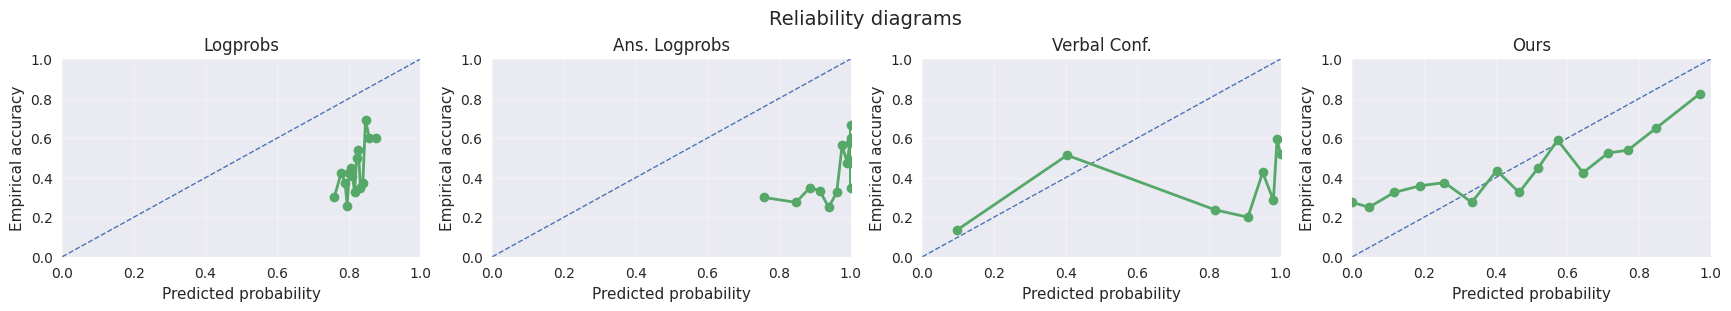

[status] running Qwen/Qwen3-14B
webq Qwen/Qwen3-14B no rows 991


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,Qwen/Qwen3-14B,webq,logprob,0.344251,0.354640,0.473404,0.979339,0.360990,0.625787,0.477311
1,Qwen/Qwen3-14B,webq,ans_logprob,0.468871,0.479400,0.659563,3.131830,0.463744,0.612540,0.477311
2,Qwen/Qwen3-14B,webq,oracle_sc,0.155664,0.180657,0.337778,0.846566,0.248148,0.691335,0.477311
3,Qwen/Qwen3-14B,webq,ridge_clip,0.151452,0.191698,0.356927,1.112696,0.271928,0.627310,0.477311
4,Qwen/Qwen3-14B,webq,split_isotonic_on_ridge,0.099964,0.142224,0.258764,0.730547,0.255183,0.627502,0.477311
5,Qwen/Qwen3-14B,webq,split_isotonic_on_ridge_nrt,0.102993,0.132541,0.290929,0.715696,0.253037,0.627604,0.477311
6,Qwen/Qwen3-14B,webq,verbal_conf,0.390084,0.418128,0.579636,1.584870,0.396594,0.670407,0.477311
7,Qwen/Qwen3-14B,webq,blackbox_ridge_clip,0.143131,0.164184,0.279099,1.014934,0.254740,0.655422,0.477311
8,Qwen/Qwen3-14B,webq,blackbox_split_isotonic_on_ridge,0.087653,0.111406,0.194964,0.688505,0.241027,0.657777,0.477311
9,Qwen/Qwen3-14B,webq,blackbox_split_isotonic_on_ridge_nrt,0.094783,0.127384,0.218092,0.691429,0.243114,0.658179,0.477311


Qwen/Qwen3-14B webq


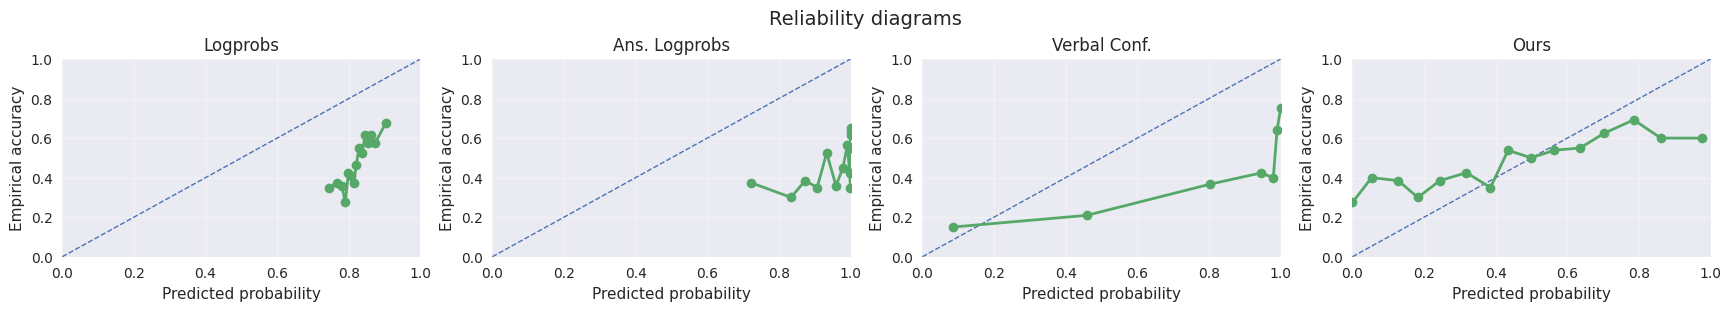

[status] running nvidia/OpenReasoning-Nemotron-7B
[status] running nvidia/Nemotron-Cascade-8B-Thinking
webq nvidia/Nemotron-Cascade-8B-Thinking no rows 996


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
0,nvidia/Nemotron-Cascade-8B-Thinking,webq,logprob,0.437031,0.451275,0.582774,1.186449,0.428333,0.650162,0.428094
1,nvidia/Nemotron-Cascade-8B-Thinking,webq,ans_logprob,0.526727,0.533186,0.715413,3.409421,0.515948,0.610689,0.428094
2,nvidia/Nemotron-Cascade-8B-Thinking,webq,oracle_sc,0.105000,0.141230,0.336800,0.750008,0.227017,0.698191,0.428094
3,nvidia/Nemotron-Cascade-8B-Thinking,webq,ridge_clip,0.090357,0.127768,0.290139,0.816723,0.230638,0.670670,0.428094
4,nvidia/Nemotron-Cascade-8B-Thinking,webq,split_isotonic_on_ridge,0.072174,0.102669,0.239016,0.655830,0.226713,0.665599,0.428094
5,nvidia/Nemotron-Cascade-8B-Thinking,webq,split_isotonic_on_ridge_nrt,0.089989,0.108482,0.196949,0.662593,0.229262,0.673543,0.428094
6,nvidia/Nemotron-Cascade-8B-Thinking,webq,verbal_conf,0.450886,0.467981,0.577548,2.575290,0.455852,0.615657,0.428094
7,nvidia/Nemotron-Cascade-8B-Thinking,webq,blackbox_ridge_clip,0.091877,0.127911,0.359525,0.985798,0.231592,0.674194,0.428094
8,nvidia/Nemotron-Cascade-8B-Thinking,webq,blackbox_split_isotonic_on_ridge,0.064495,0.083279,0.164333,0.648973,0.226345,0.664891,0.428094
9,nvidia/Nemotron-Cascade-8B-Thinking,webq,blackbox_split_isotonic_on_ridge_nrt,0.059768,0.091173,0.198696,0.660693,0.230195,0.654914,0.428094


nvidia/Nemotron-Cascade-8B-Thinking webq


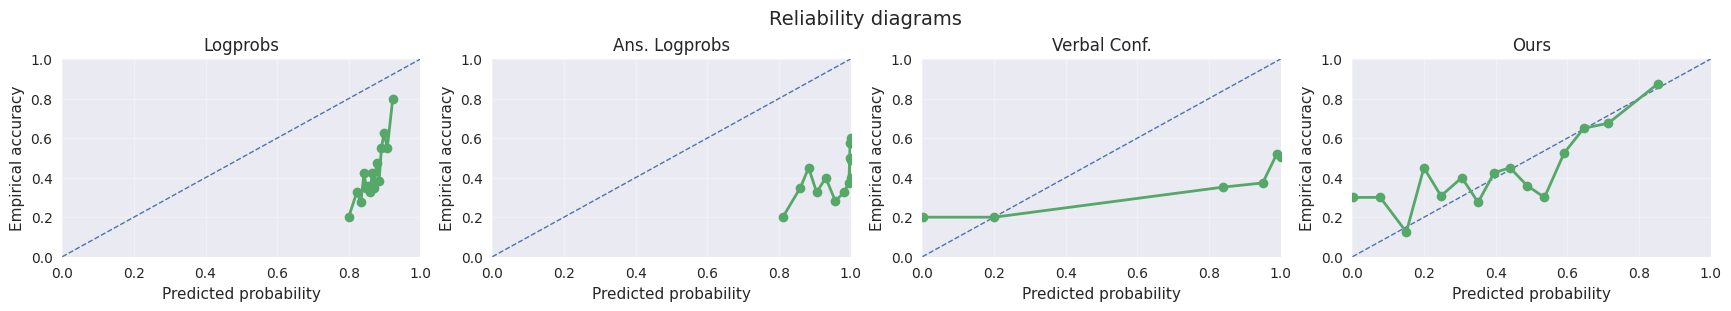

[status] running deepseek-ai/DeepSeek-R1-Distill-Llama-8B
[status] running deepseek-ai/DeepSeek-R1-Distill-Qwen-7B
--- 874.8147418498993 seconds ---


,Model,Dataset,Method,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy,seed
0,Qwen/Qwen3-0.6B,gsm8k,logprob,0.074230,0.087404,0.149404,0.471943,0.149191,0.689263,0.806344,0
1,Qwen/Qwen3-0.6B,gsm8k,ans_logprob,0.189862,0.250154,0.634738,1.869455,0.187854,0.727324,0.806344,0
2,Qwen/Qwen3-0.6B,gsm8k,oracle_sc,0.053940,0.071886,0.169434,0.419116,0.103103,0.871064,0.806344,0
3,Qwen/Qwen3-0.6B,gsm8k,ridge_clip,0.093570,0.103760,0.187311,0.858076,0.155720,0.651103,0.806344,0
4,Qwen/Qwen3-0.6B,gsm8k,split_isotonic_on_ridge,0.060409,0.066279,0.110943,0.521132,0.151273,0.650559,0.806344,0


AVERAGE


,ECE1,ECE2,MCE,Brier,AUROC
Method,,,,,
logprob_scaled,0.052899,0.065568,0.133692,0.160519,0.653098
ans_logprob_scaled,0.055892,0.069104,0.142323,0.159773,0.620659
question_only_split_isotonic_on_ridge_nrt,0.065318,0.077732,0.173808,0.164071,0.635141
question_only_split_isotonic_on_ridge,0.068021,0.082267,0.184936,0.164443,0.640340
split_isotonic_on_ridge,0.068940,0.086282,0.200956,0.154973,0.710962
split_isotonic_on_ridge_nrt,0.069416,0.086301,0.198592,0.155102,0.707654
blackbox_split_isotonic_on_ridge,0.068919,0.086650,0.197148,0.154464,0.712467
blackbox_split_isotonic_on_ridge_nrt,0.069210,0.087227,0.199568,0.154810,0.708505
blackbox_ridge_clip,0.073913,0.092273,0.192251,0.154172,0.718038


WORST


,ECE1,ECE2,MCE,Brier
Method,,,,
logprob_scaled,0.093192,0.110313,0.206200,0.250617
question_only_split_isotonic_on_ridge_nrt,0.118673,0.134373,0.283712,0.256245
question_only_split_isotonic_on_ridge,0.121057,0.148884,0.318479,0.259777
split_isotonic_on_ridge_nrt,0.127420,0.149154,0.300615,0.252351
blackbox_split_isotonic_on_ridge_nrt,0.125943,0.149174,0.300228,0.254589
split_isotonic_on_ridge,0.131588,0.153237,0.303103,0.252895
blackbox_split_isotonic_on_ridge,0.133732,0.157009,0.303664,0.256781
ans_logprob_scaled,0.143229,0.164912,0.290252,0.250265
ridge_clip,0.158069,0.185398,0.388729,0.266428


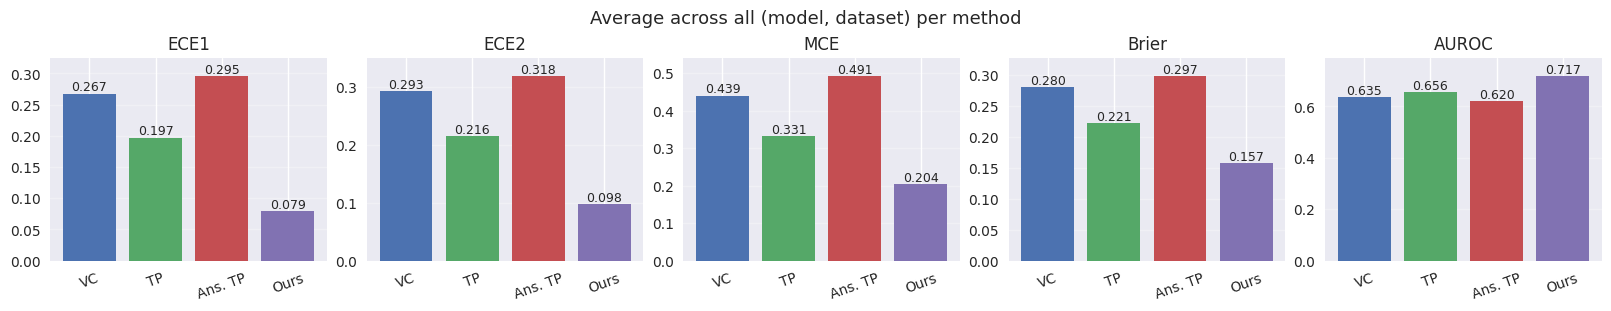

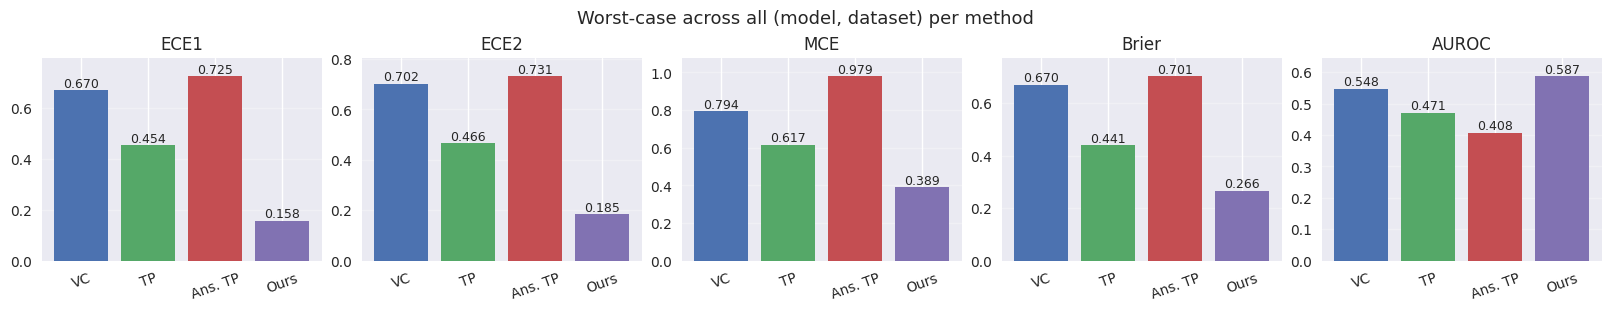

----------------------------------------
--* Dataset comparison *--
----------------------------------------


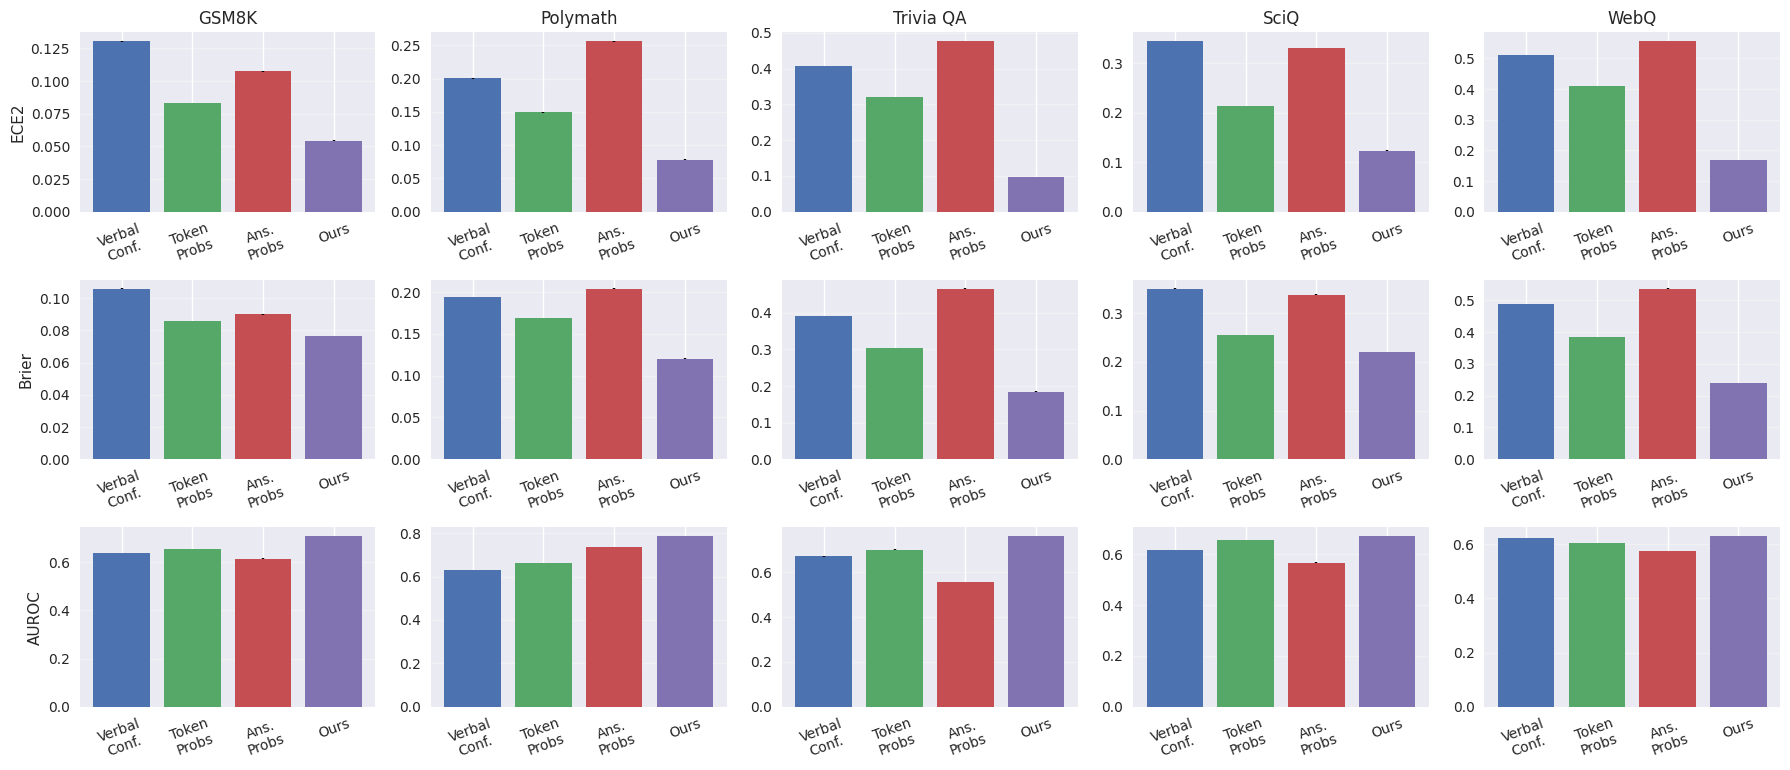

gsm8k


,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
Method,,,,,,,
ans_logprob,0.089301,0.107441,0.221072,0.976500,0.090031,0.615340,0.90815
ans_logprob_scaled,0.032997,0.042274,0.099429,0.280495,0.076022,0.633860,0.90815
blackbox_ridge_clip,0.042531,0.052441,0.112867,0.410184,0.074778,0.699816,0.90815
blackbox_split_isotonic_on_ridge,0.043037,0.054723,0.126646,0.317957,0.076372,0.692366,0.90815
blackbox_split_isotonic_on_ridge_nrt,0.044771,0.057304,0.130320,0.311555,0.076838,0.689183,0.90815
logprob,0.075141,0.083225,0.134781,0.310178,0.085941,0.655202,0.90815
logprob_scaled,0.037597,0.047477,0.100948,0.287412,0.079223,0.641684,0.90815
oracle_sc,0.043579,0.057086,0.139492,0.398231,0.065141,0.797504,0.90815
question_only_ridge_clip,0.055298,0.063728,0.113910,0.518412,0.084438,0.585479,0.90815


polymath


,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
Method,,,,,,,
ans_logprob,0.205411,0.255863,0.538053,1.884255,0.204038,0.734763,0.780378
ans_logprob_scaled,0.049194,0.061127,0.127006,0.370284,0.111866,0.735072,0.780378
blackbox_ridge_clip,0.061043,0.082813,0.201690,0.459971,0.116905,0.798857,0.780378
blackbox_split_isotonic_on_ridge,0.069233,0.093629,0.214134,0.405936,0.121009,0.792427,0.780378
blackbox_split_isotonic_on_ridge_nrt,0.071891,0.097576,0.225538,0.410809,0.123127,0.781265,0.780378
logprob,0.129669,0.149011,0.250627,0.522082,0.169149,0.661068,0.780378
logprob_scaled,0.054069,0.067883,0.141632,0.432505,0.140618,0.665443,0.780378
oracle_sc,0.066843,0.098003,0.235027,0.400342,0.101030,0.875554,0.780378
question_only_ridge_clip,0.064181,0.078051,0.159315,0.547610,0.129784,0.728698,0.780378


trivia_qa


...

sciq


,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
Method,,,,,,,
ans_logprob,0.316753,0.331653,0.481694,1.924960,0.337786,0.567008,0.61534
ans_logprob_scaled,0.071879,0.088255,0.175606,0.645989,0.226640,0.548830,0.61534
blackbox_ridge_clip,0.085986,0.105114,0.207842,0.751467,0.213697,0.675328,0.61534
blackbox_split_isotonic_on_ridge,0.060873,0.076898,0.193145,0.621445,0.210731,0.670913,0.61534
blackbox_split_isotonic_on_ridge_nrt,0.056829,0.070964,0.185372,0.610670,0.208658,0.676254,0.61534
logprob,0.185678,0.213948,0.371407,0.725171,0.255554,0.656252,0.61534
logprob_scaled,0.059628,0.073137,0.145405,0.615146,0.213011,0.656252,0.61534
oracle_sc,0.093771,0.111013,0.202383,0.706504,0.199657,0.725411,0.61534
question_only_ridge_clip,0.118154,0.142513,0.270769,0.834841,0.237022,0.605898,0.61534


webq


,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
Method,,,,,,,
ans_logprob,0.548335,0.556563,0.706973,3.461797,0.536757,0.574119,0.383783
ans_logprob_scaled,0.070193,0.085682,0.168352,0.645332,0.227132,0.568590,0.383783
blackbox_ridge_clip,0.132655,0.162444,0.315049,0.963180,0.240477,0.622242,0.383783
blackbox_split_isotonic_on_ridge,0.109847,0.132078,0.280424,0.687612,0.233451,0.619313,0.383783
blackbox_split_isotonic_on_ridge_nrt,0.105106,0.127396,0.272245,0.680002,0.233180,0.611846,0.383783
logprob,0.399210,0.409206,0.536933,1.030852,0.385726,0.603729,0.383783
logprob_scaled,0.063203,0.076946,0.151238,0.637120,0.222954,0.600294,0.383783
oracle_sc,0.137569,0.168286,0.326304,0.781135,0.231582,0.664204,0.383783
question_only_ridge_clip,0.143697,0.173919,0.332621,0.943867,0.249766,0.591832,0.383783


----------------------------------------
--* Model comparison *--
----------------------------------------


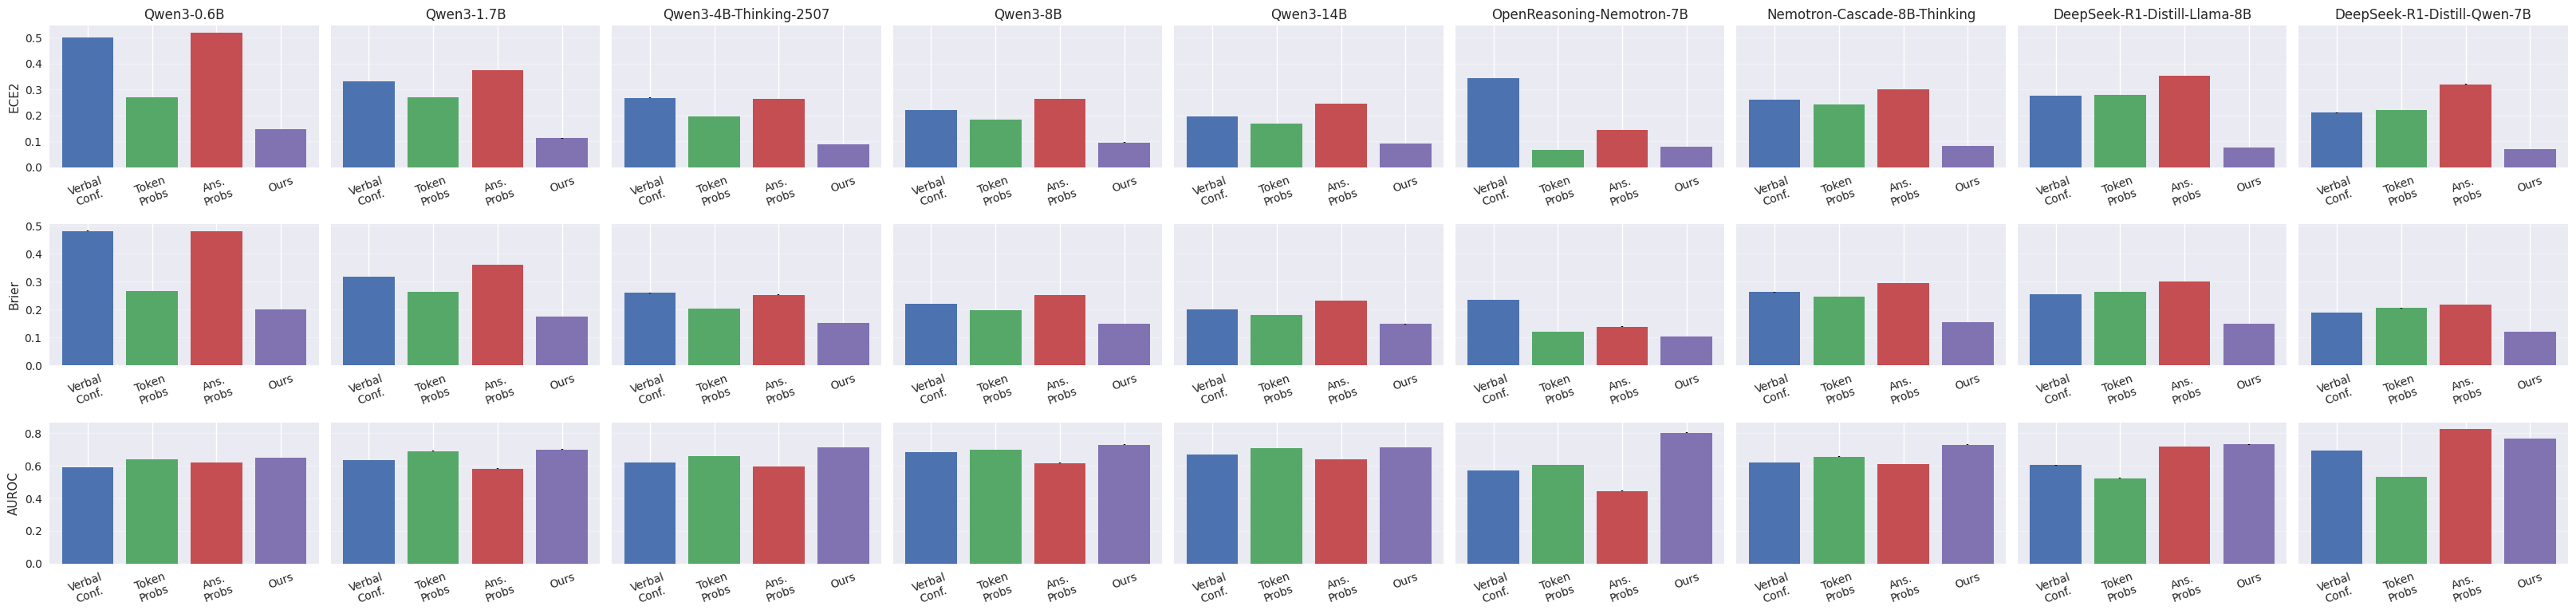

Qwen/Qwen3-0.6B


,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
Method,,,,,,,
ans_logprob,0.493474,0.519374,0.731397,3.175197,0.480531,0.621019,0.457635
ans_logprob_scaled,0.083382,0.100226,0.196224,0.562587,0.187612,0.616378,0.457635
blackbox_ridge_clip,0.090245,0.108431,0.207118,0.614024,0.177887,0.701967,0.457635
blackbox_split_isotonic_on_ridge,0.083560,0.100454,0.220201,0.541671,0.178460,0.696133,0.457635
blackbox_split_isotonic_on_ridge_nrt,0.084929,0.103017,0.234320,0.540053,0.178886,0.694652,0.457635
logprob,0.255817,0.269422,0.374228,0.724658,0.266467,0.640373,0.457635
logprob_scaled,0.057024,0.070519,0.142836,0.547773,0.182792,0.636473,0.457635
oracle_sc,0.082736,0.102798,0.207588,0.507543,0.157975,0.778580,0.457635
question_only_ridge_clip,0.135105,0.162294,0.312787,0.878114,0.210332,0.601937,0.457635


Qwen/Qwen3-1.7B


,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
Method,,,,,,,
ans_logprob,0.362062,0.373633,0.510047,3.137848,0.361652,0.583518,0.615346
ans_logprob_scaled,0.046175,0.056592,0.111874,0.534648,0.180611,0.576415,0.615346
blackbox_ridge_clip,0.082772,0.104025,0.219323,0.672225,0.169468,0.714707,0.615346
blackbox_split_isotonic_on_ridge,0.080510,0.101509,0.226582,0.535197,0.170784,0.710148,0.615346
blackbox_split_isotonic_on_ridge_nrt,0.080747,0.102767,0.230878,0.531986,0.171302,0.707209,0.615346
logprob,0.247002,0.268821,0.395411,0.735196,0.264617,0.691596,0.615346
logprob_scaled,0.051952,0.065363,0.137343,0.510757,0.171540,0.691373,0.615346
oracle_sc,0.089063,0.112482,0.234772,0.578301,0.153319,0.779582,0.615346
question_only_ridge_clip,0.102896,0.122180,0.229661,0.786364,0.187636,0.633270,0.615346


Qwen/Qwen3-4B-Thinking-2507


...

,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
Method,,,,,,,
ans_logprob,0.292351,0.301070,0.420439,2.436785,0.294174,0.612017,0.685262
ans_logprob_scaled,0.053523,0.068566,0.148935,0.506844,0.170611,0.608341,0.685262
blackbox_ridge_clip,0.071136,0.089967,0.196409,0.643296,0.161044,0.703857,0.685262
blackbox_split_isotonic_on_ridge,0.061648,0.078546,0.186273,0.509593,0.160071,0.698357,0.685262
blackbox_split_isotonic_on_ridge_nrt,0.061532,0.078160,0.188049,0.504431,0.160677,0.693258,0.685262
logprob,0.222134,0.241330,0.388997,0.726044,0.245905,0.657311,0.685262
logprob_scaled,0.051776,0.064605,0.133626,0.497781,0.164739,0.656555,0.685262
oracle_sc,0.080355,0.099133,0.198300,0.608841,0.145984,0.768925,0.685262
question_only_ridge_clip,0.065597,0.080295,0.163210,0.593519,0.168320,0.653662,0.685262


deepseek-ai/DeepSeek-R1-Distill-Llama-8B


,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
Method,,,,,,,
ans_logprob,0.313116,0.352622,0.714588,2.918318,0.300737,0.718488,0.668049
ans_logprob_scaled,0.027456,0.034359,0.074899,0.417137,0.132720,0.718526,0.668049
blackbox_ridge_clip,0.066890,0.079660,0.148401,0.568951,0.147190,0.733289,0.668049
blackbox_split_isotonic_on_ridge,0.063427,0.076590,0.174962,0.475555,0.149120,0.728673,0.668049
blackbox_split_isotonic_on_ridge_nrt,0.062729,0.076250,0.176150,0.468261,0.148997,0.733174,0.668049
logprob,0.262697,0.279332,0.393220,0.770091,0.263091,0.524902,0.668049
logprob_scaled,0.073966,0.090192,0.181248,0.541080,0.181586,0.494532,0.668049
oracle_sc,0.055421,0.071083,0.149014,0.411126,0.128556,0.839294,0.668049
question_only_ridge_clip,0.069713,0.082686,0.154049,0.582655,0.155431,0.681717,0.668049


deepseek-ai/DeepSeek-R1-Distill-Qwen-7B


,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
Method,,,,,,,
ans_logprob,0.226026,0.320009,0.690593,1.520069,0.217142,0.824852,0.760531
ans_logprob_scaled,0.087116,0.106352,0.223728,0.361409,0.093301,0.824847,0.760531
blackbox_ridge_clip,0.056985,0.068386,0.134543,0.503513,0.122823,0.747831,0.760531
blackbox_split_isotonic_on_ridge,0.059853,0.076249,0.167569,0.421391,0.126507,0.742619,0.760531
blackbox_split_isotonic_on_ridge_nrt,0.060444,0.078033,0.170036,0.419719,0.129034,0.737526,0.760531
logprob,0.199286,0.221040,0.325712,0.640483,0.205142,0.533558,0.760531
logprob_scaled,0.063832,0.076444,0.144782,0.483902,0.158725,0.525587,0.760531
oracle_sc,0.051653,0.062750,0.124260,0.415370,0.102831,0.838151,0.760531
question_only_ridge_clip,0.063350,0.075986,0.146959,0.528807,0.130303,0.688522,0.760531


In [16]:
models = [
    "Qwen/Qwen3-0.6B", 
    "Qwen/Qwen3-1.7B", 
    "Qwen/Qwen3-4B-Thinking-2507", 
    "Qwen/Qwen3-8B",
    "Qwen/Qwen3-14B",
    "nvidia/OpenReasoning-Nemotron-7B",
    "nvidia/Nemotron-Cascade-8B-Thinking",
    "deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
]
datasets = [
    "gsm8k",
    "polymath",
    "trivia_qa",
    "sciq",
    "webq"
]
exp_key = "all"
n_trials = 200

# exp_key = "test"
# n_trials = 1

run_all_exps(models, datasets, exp_key, n_trials)